# its2_ps_processing

In [3]:
require(data.table)
require(tidyverse)
require(phyloseq)
require(ggplot2)
require(RColorBrewer)
require(metacoder)
require(vegan)
require(DESeq2)
options(repr.plot.width=20, repr.plot.height=15)

In [2]:
ps<-readRDS(file = "/work/pi_sarah_gignouxwolfsohn_uml_edu/caroline/BEL_16S_ITS2/BEL_ITS2_outputs/ps_all_ITS2.rds")
#removing any taxa that don't show up in any samples to speed up the process
ps

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 257 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 257 taxa by 8 taxonomic ranks ]

## investigate read counts

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


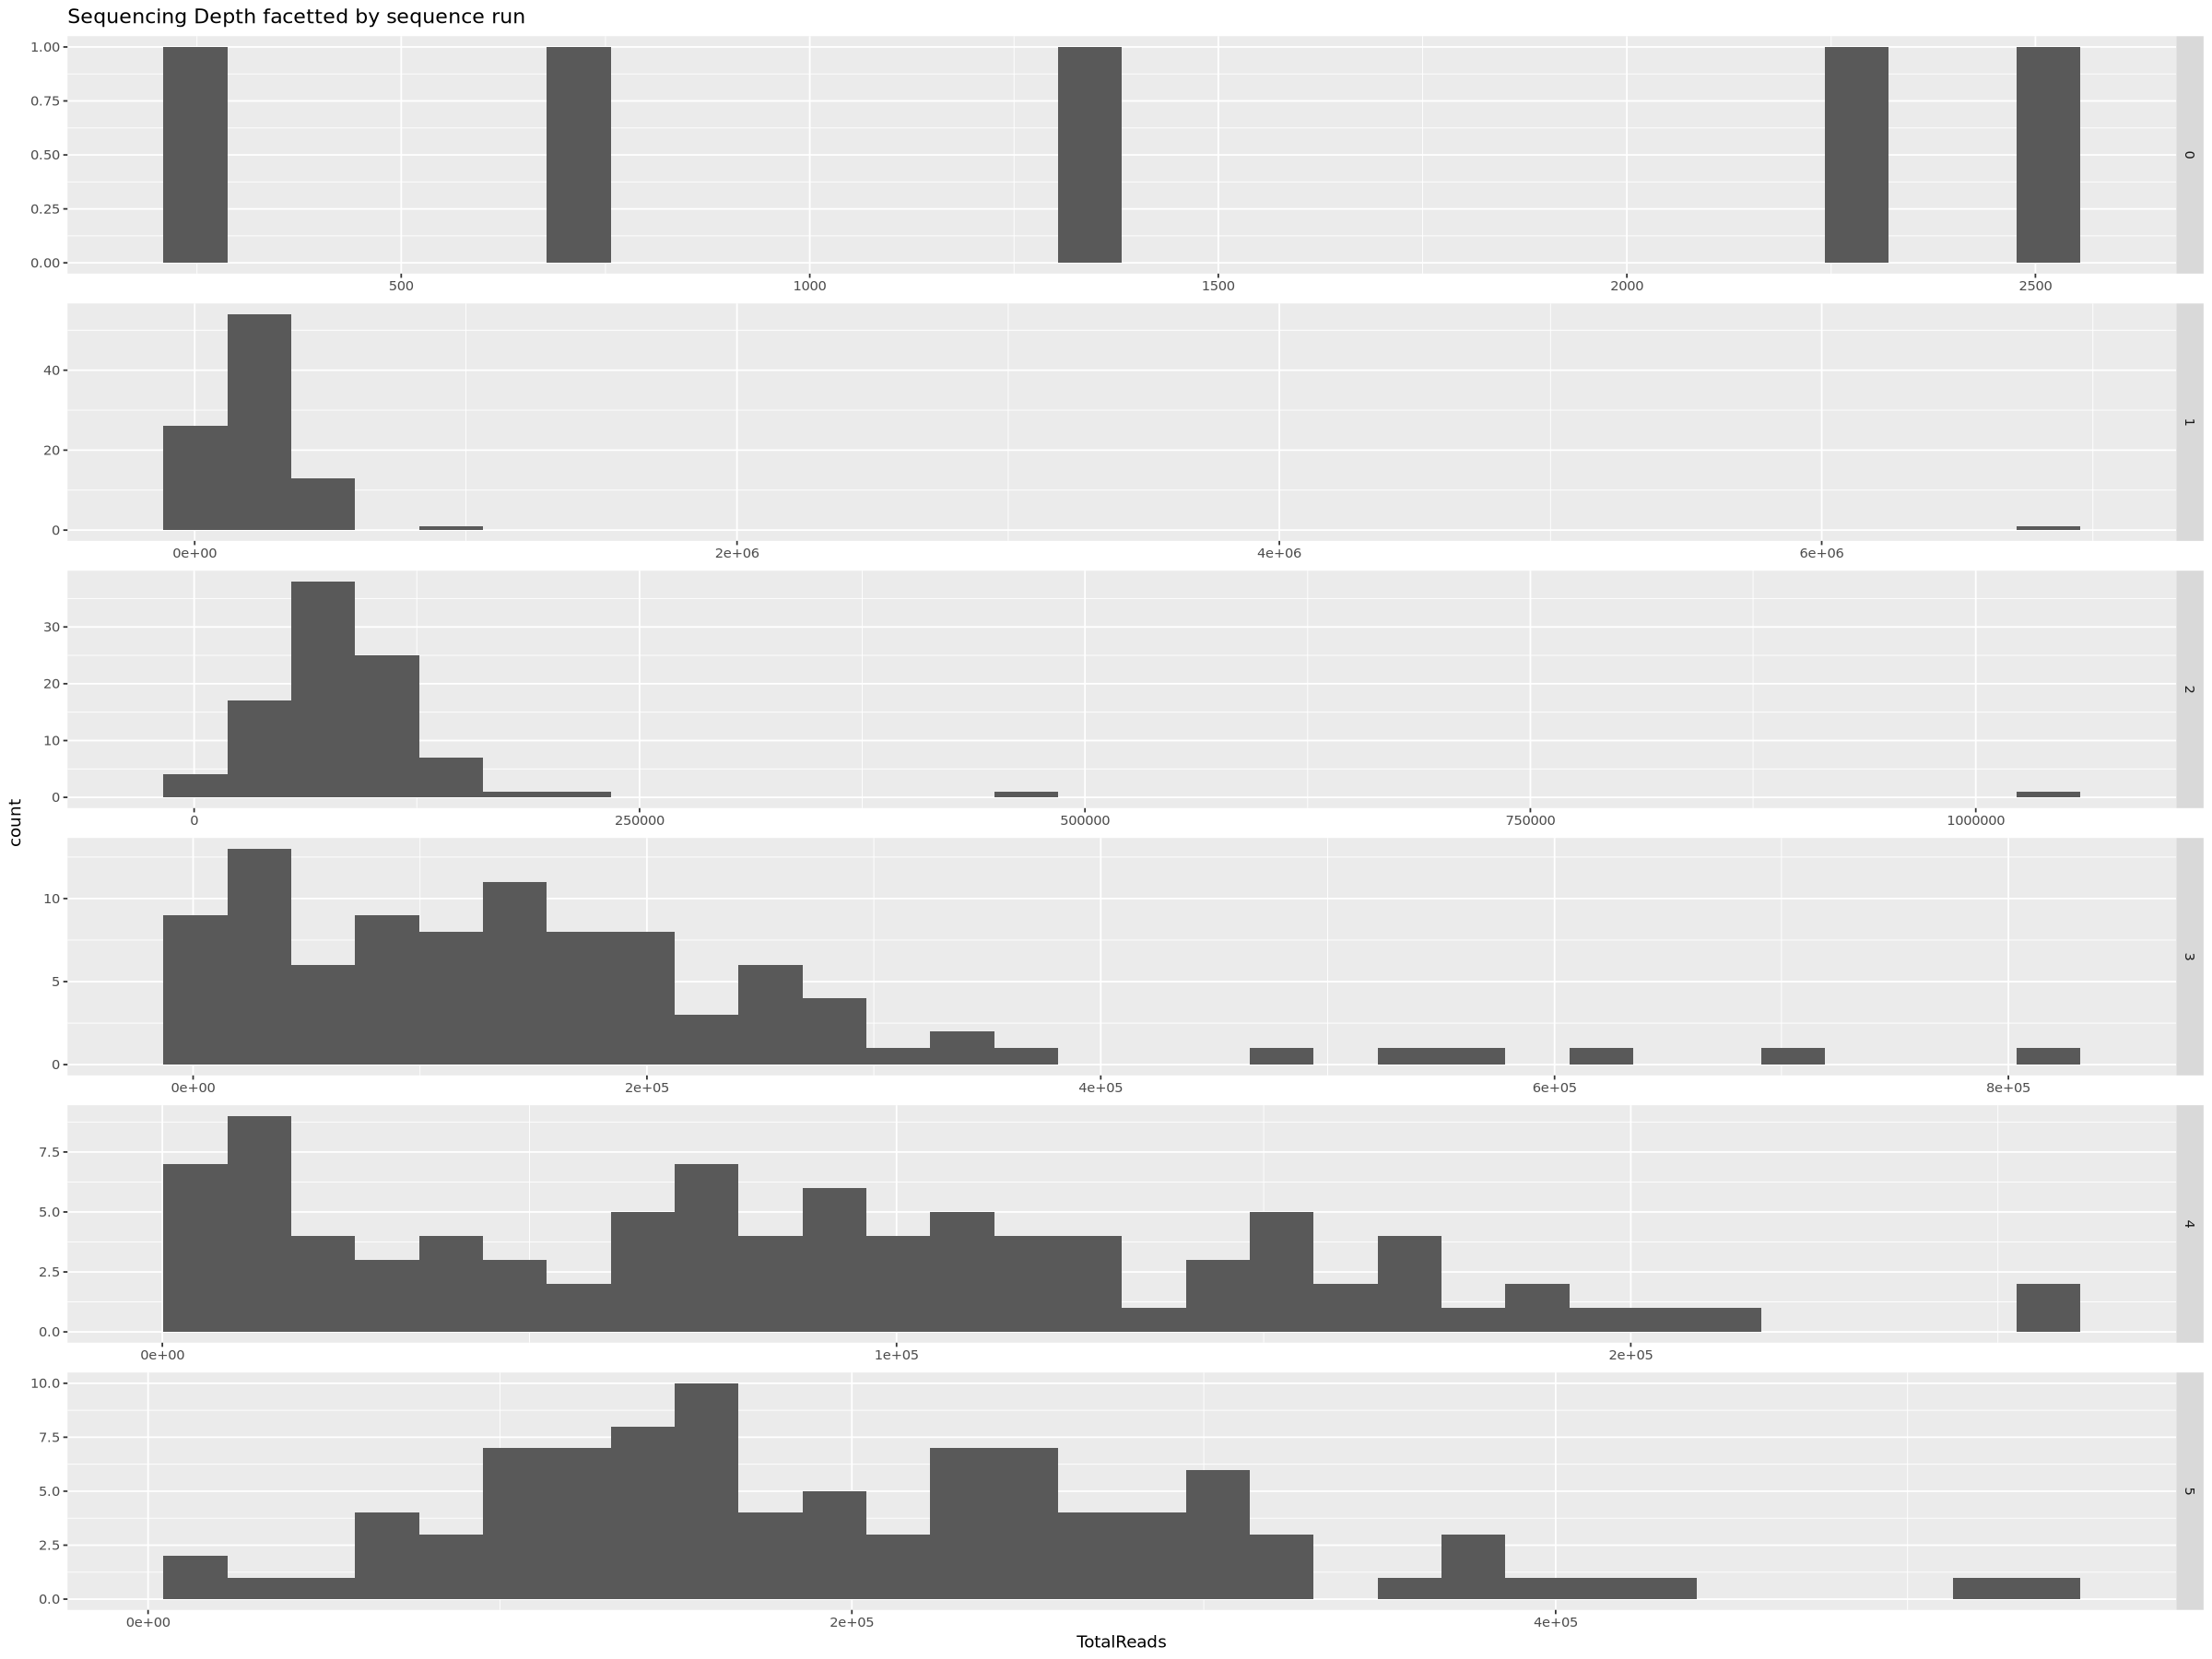

In [4]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sequence run") + facet_wrap(Seq_run ~., strip.position = "right",  ncol = 1, scales="free")  # Set desired font size

In [5]:
total_reads <- print(readcount[order(readcount$TotalReads), c("SampleID", "TotalReads")])

# median reads
median(readcount$TotalReads)

# mean reads
mean(readcount$TotalReads)

# minimum read number
readcount[, min(TotalReads)]

                       SampleID TotalReads
                         <char>      <num>
  1:                 Negative_2        248
  2: 122023_BEL_CBC_T1_506_PAST        663
  3:                   Negative        749
  4:  102019_BEL_CBC_T3_35_PSTR        970
  5:  122022_BEL_CBC_T4_34_PSTR       1271
 ---                                      
475: 122022_BEL_CBC_T1_123_OANN     691980
476: 122023_BEL_CBC_T2_521_OFAV     817667
477: 012024_BEL_CBC_T2_601_OFAV     919773
478:   052022_BEL_CBC_T3_1_MCAV    1040804
479: 012024_BEL_CBC_T3_637_SSID    6836288


[1] 117183

[1] 166695.5

[1] 248

## list samples with under 5K reads

In [36]:
class(total_reads)

[1] "data.table" "data.frame"

In [38]:
# Subset rows where 'column_name' is under 5000
result <- total_reads[TotalReads < 5000]

In [39]:
print(result)

                      SampleID TotalReads
                        <char>      <num>
 1:                 Negative_2        248
 2: 122023_BEL_CBC_T1_506_PAST        663
 3:                   Negative        749
 4:  102019_BEL_CBC_T3_35_PSTR        970
 5:  122022_BEL_CBC_T4_34_PSTR       1271
 6:                 Negative_5       1358
 7: 112023_BEL_CBC_T1_273_PAST       2080
 8:                 Negative_3       2253
 9: 122023_BEL_CBC_T1_507_PAST       2368
10: 042024_BEL_CBC_T3_956_MCAV       2373
11:                 Negative_4       2516
12: 112023_BEL_CBC_T1_274_PAST       3221
13: 092023_BEL_CBC_T3_172_PSTR       4491
14: 112023_BEL_CBC_T3_355_PSTR       4529
15:  052022_BEL_CBC_T3_50_MCAV       4790
16:  052022_BEL_CBC_T1_55_PSTR       4960


## read counts by month year
- keep a look out for low read counts in bleached samples
- I don't see a low reads pattern based on month_year

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


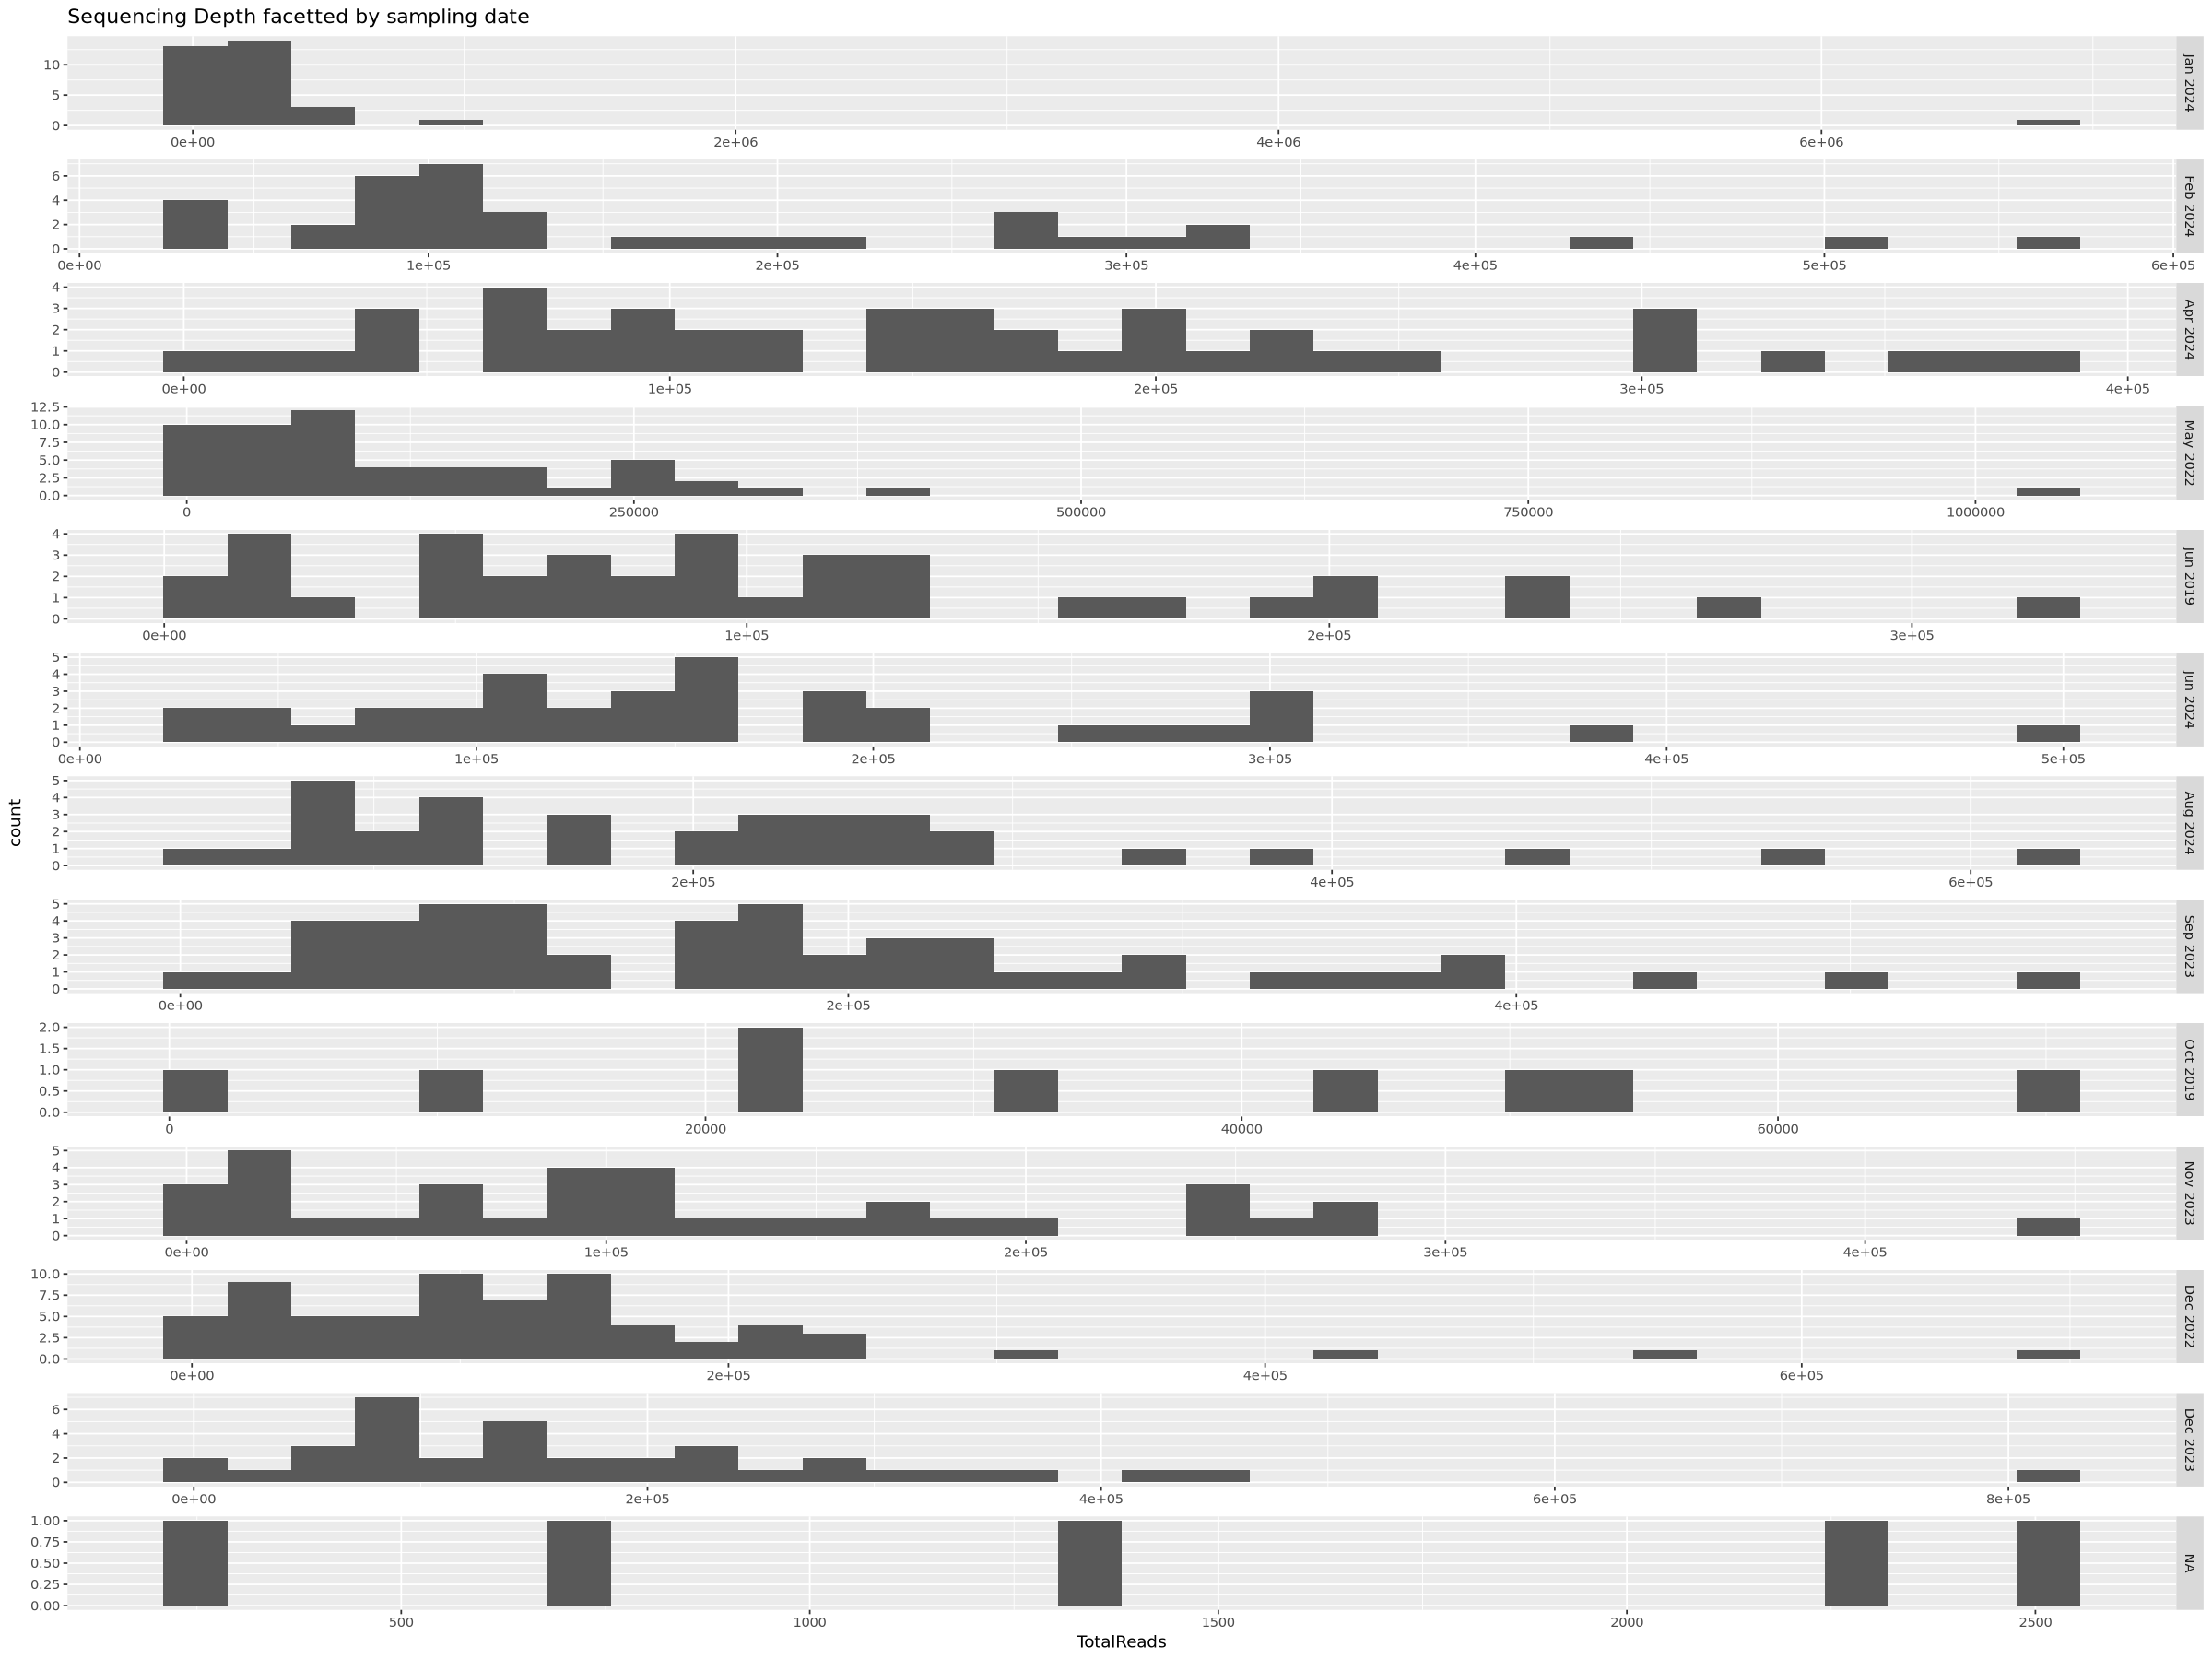

In [33]:
# Check read count
readcount = data.table(as(sample_data(ps), "data.frame"),
                 TotalReads = sample_sums(ps), 
                 keep.rownames = TRUE)
setnames(readcount, "rn", "SampleID")
ggplot(readcount, aes(TotalReads)) + geom_histogram() + ggtitle("Sequencing Depth facetted by sampling date") + facet_wrap(Month_year ~., strip.position = "right",  ncol = 1, scales="free")  # Set desired font size

## clean ps object

In [6]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune <- prune_taxa(taxa_sums(ps) > 0, ps)
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 256 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 256 taxa by 8 taxonomic ranks ]

## why don't I have any rare asv's from symportal?


In [7]:
tdt = data.table(tax_table(ps_prune),
                 TotalCounts = taxa_sums(ps_prune),
                 OTU = taxa_names(ps_prune))

Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6, 7, 8]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”
Warning message:
“Some columns are a multi-column type (such as a matrix column): [1, 2, 3, 4, 5, 6, 7, 8]. setDT will retain these columns as-is but subsequent operations like grouping and joining may fail. Please consider as.data.table() instead which will create a new column for each embedded column.”


In [8]:
# How many singletons?
tdt[(TotalCounts <= 0), .N]

tdt[(TotalCounts <= 1), .N]
# How many doubletons?
tdt[(TotalCounts <= 2), .N]


[1] 0

[1] 0

[1] 0

## rarefaction curves
- vegan wants samples as rownames and otus as columns

In [9]:
otu_df = as.data.frame(otu_table(ps_prune))
head(otu_df)

,2127725,2127449,2127776,2127296,2127758,2127760,2135884,2127728,2127766,2127763,⋯,2133817,2134340,2134451,2134452,2134972,2134002,2135463,2135550,2135480,2135536
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
012024_BEL_CBC_T1_557_SSID,0,0,0,0,0,0,469,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_559_MCAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_561_OANN,524180,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_563_PSTR,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T1_565_PAST,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
012024_BEL_CBC_T2_585_OFAV,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Warning message in rarecurve(otu_df, step = 100, label = FALSE):
“most observed count data have counts 1, but smallest count is 8”


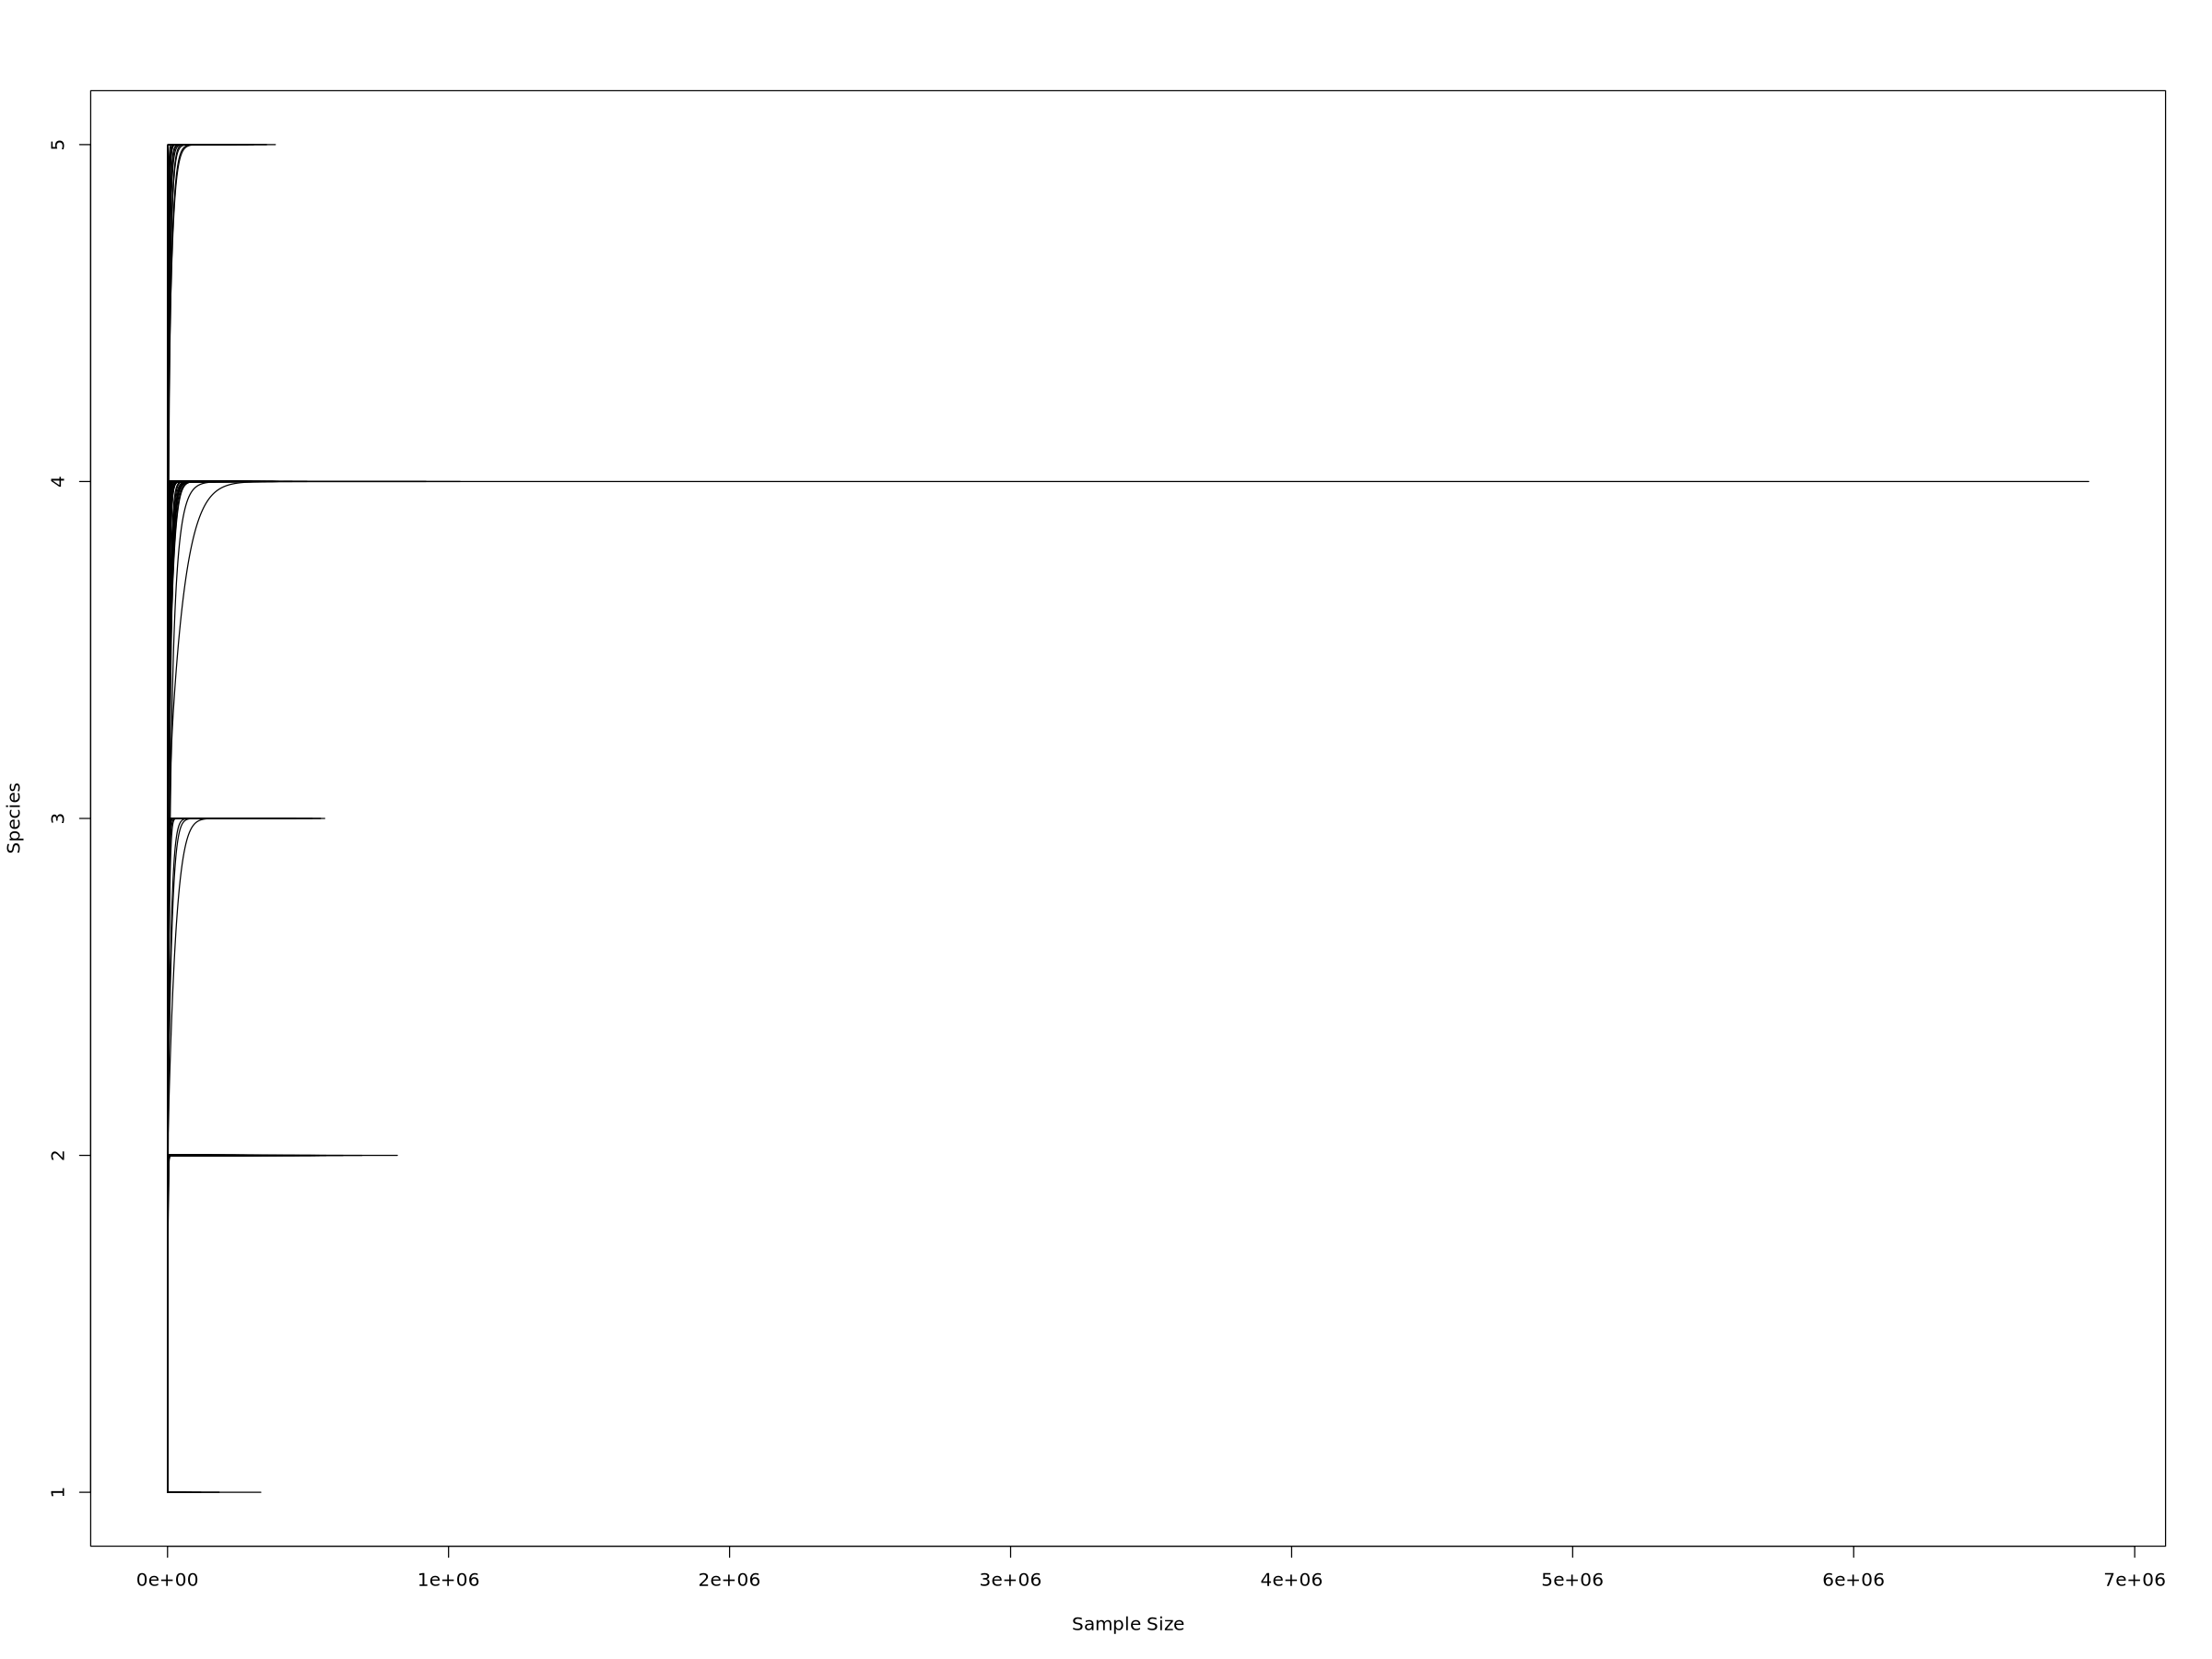

In [17]:
# we will use vegan rarecurve 
otu.rarecurve = rarecurve(otu_df, step = 100, label = FALSE)

## finding  my filtering threshold

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


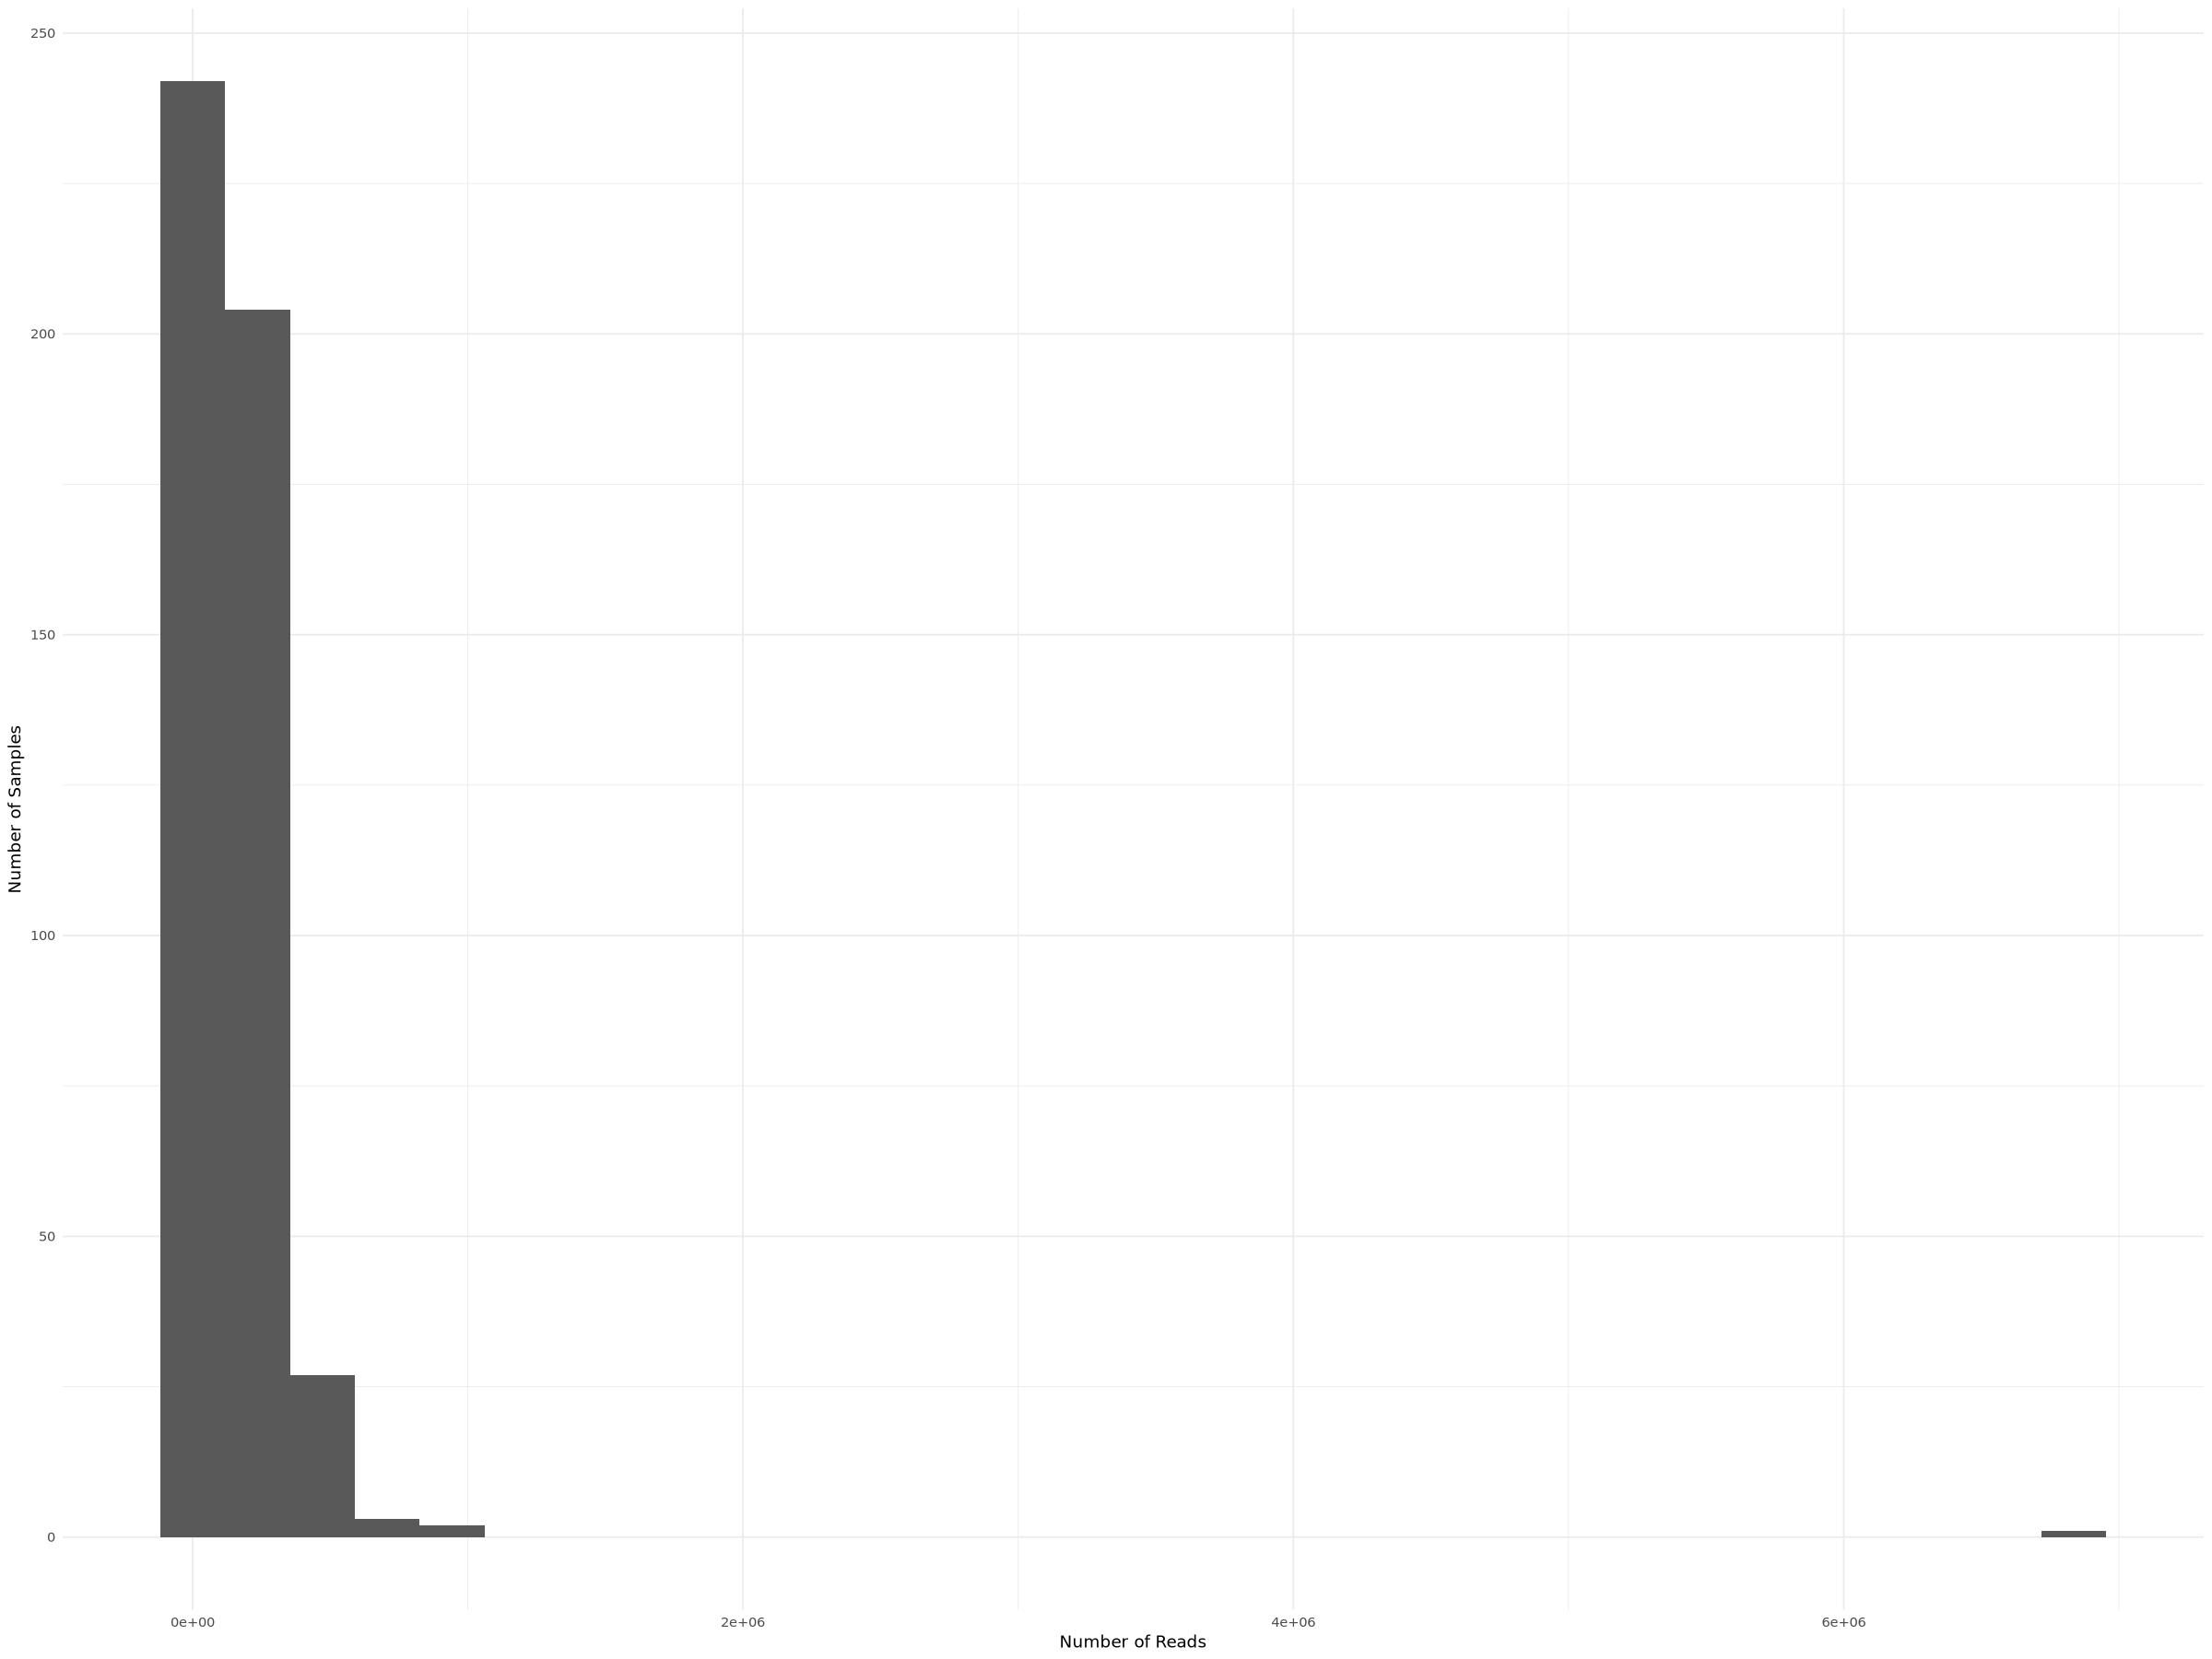

In [18]:
### where do I want to draw the filtering threshold?

readcount %>%
  ggplot(aes(x = TotalReads)) +
  geom_histogram() +   # Added width and transparency
  labs(x = "Number of Reads", y = "Number of Samples") +
  theme_minimal()

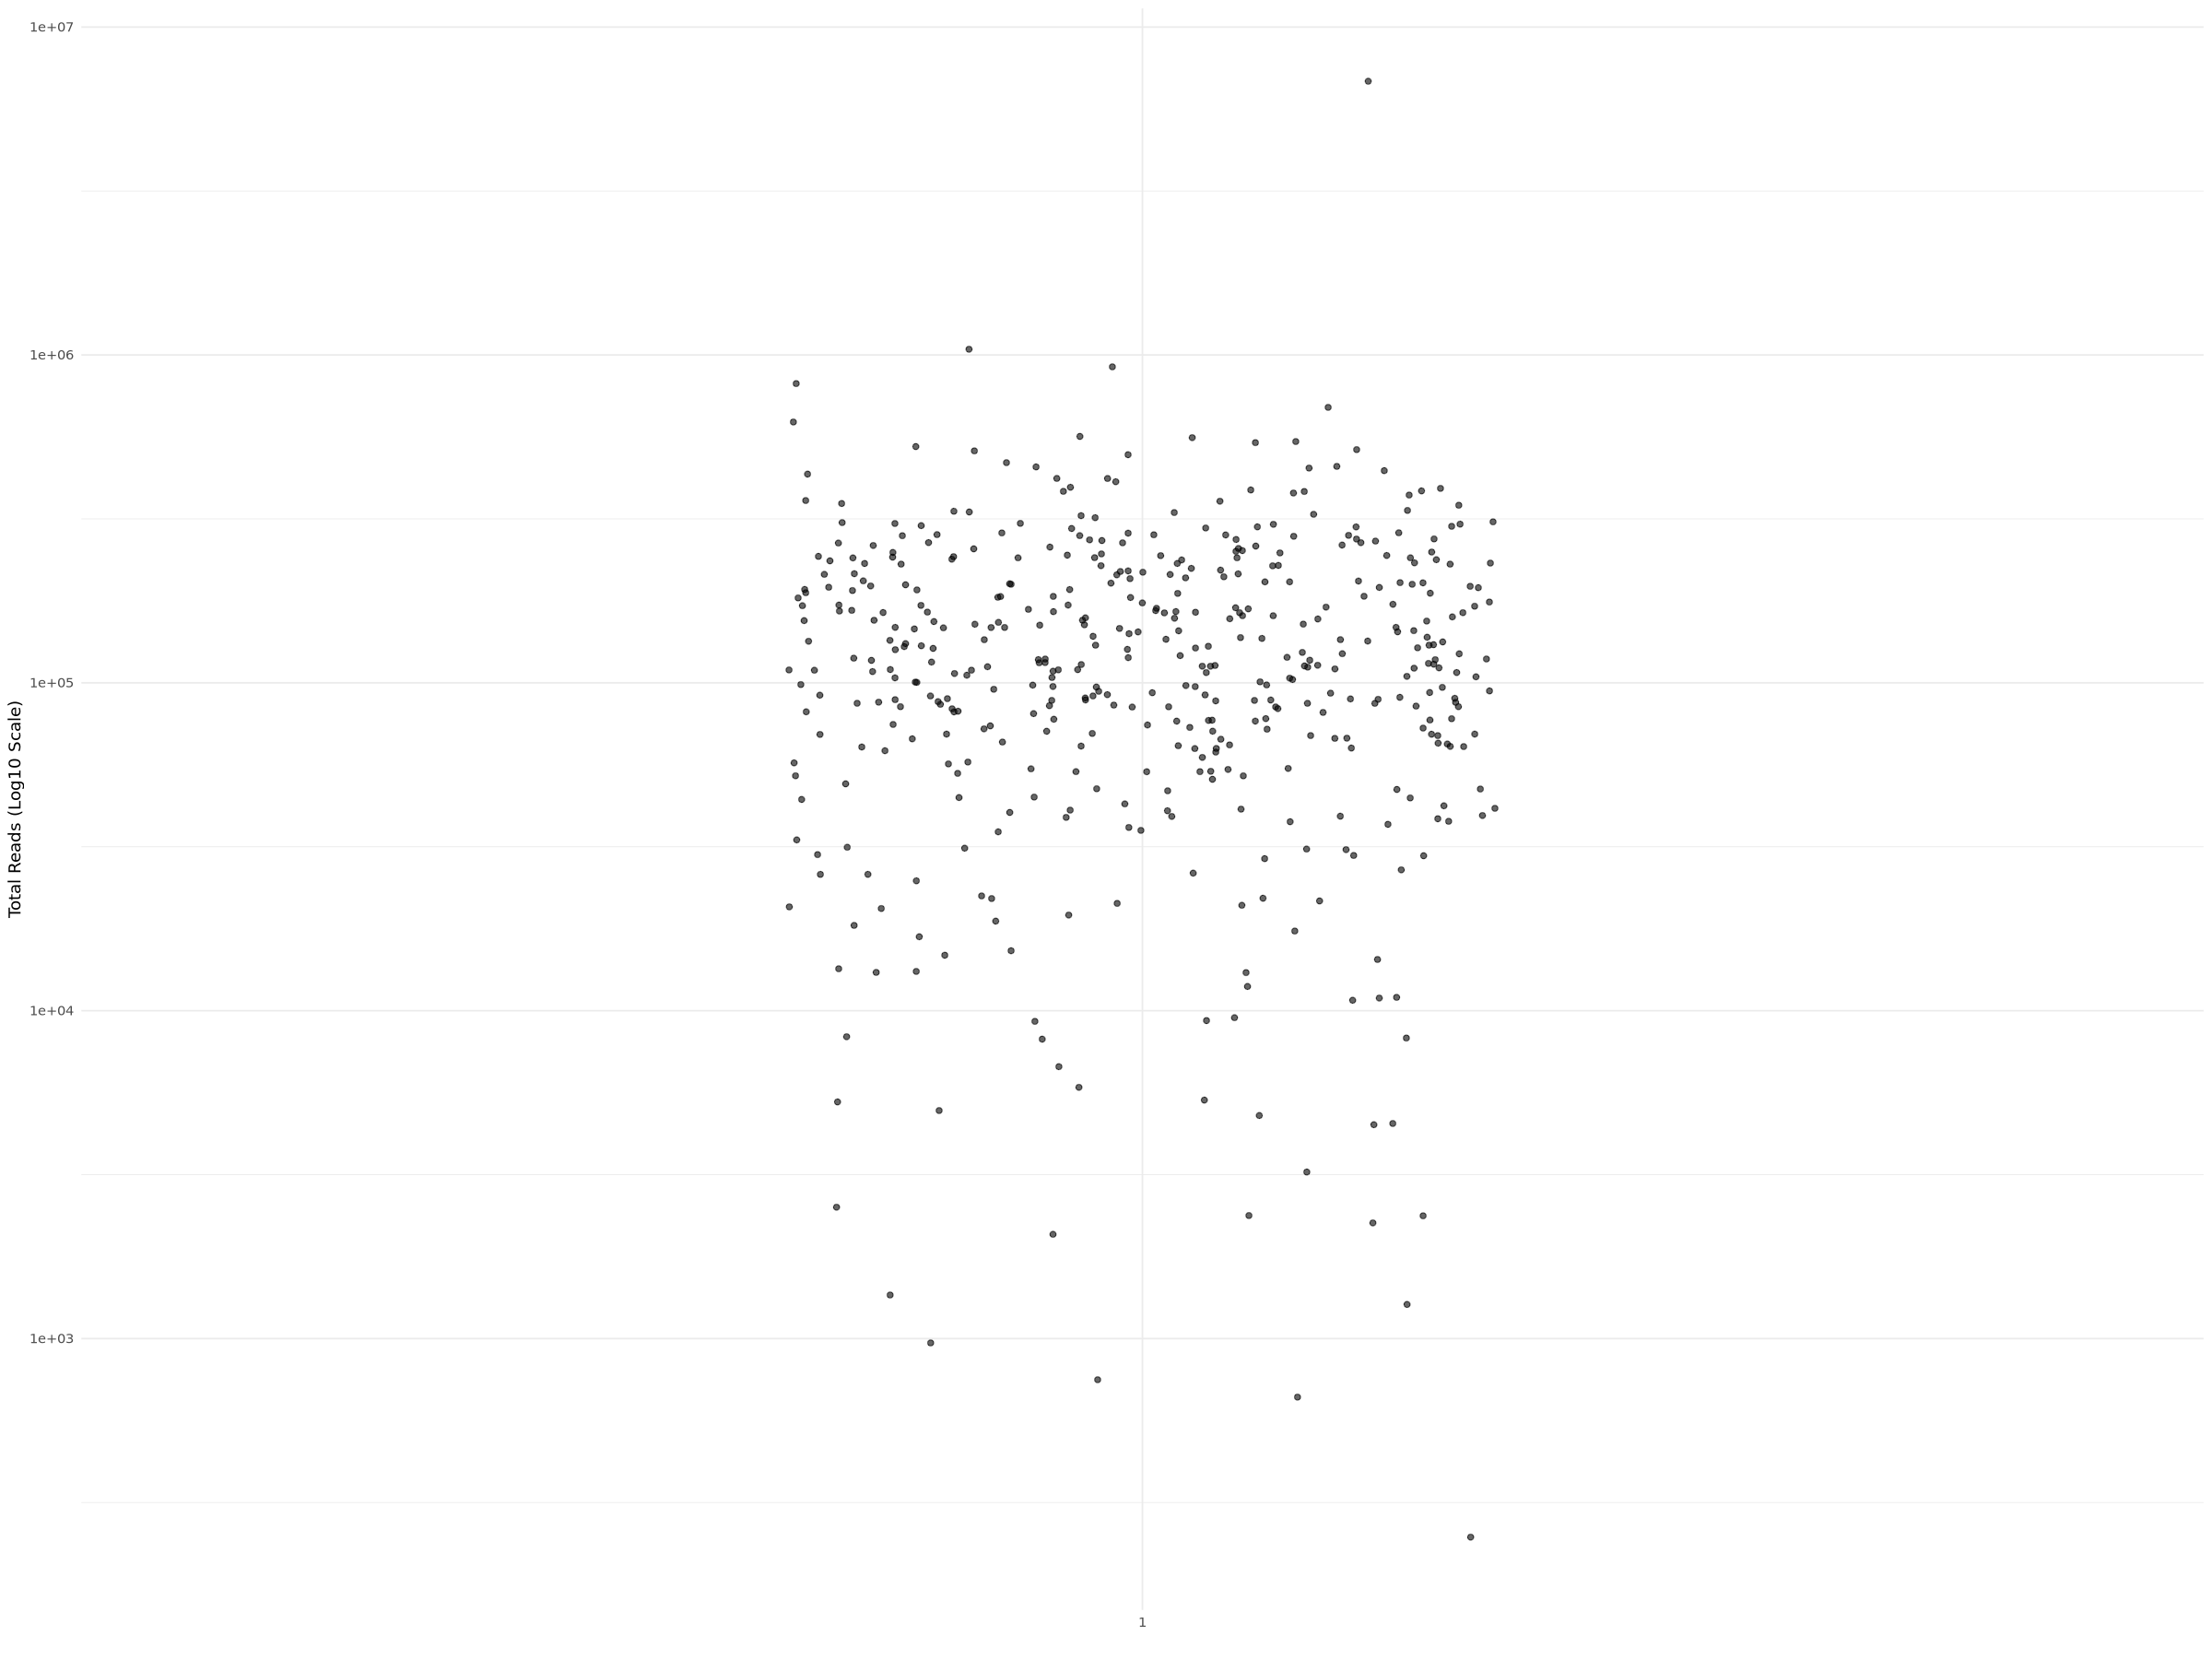

In [19]:
### where do I want to draw the filtering threshold?

readcount %>%
  ggplot(aes(x = factor(1), y = TotalReads)) +
  geom_jitter(width = 0.2, alpha = 0.6) +   # Added width and transparency
  scale_y_log10() +
  labs(x = "", y = "Total Reads (Log10 Scale)") +
  theme_minimal()


## removing samples with under 1K reads

In [10]:
# remove low read counts
ps_high <- prune_samples(sample_sums(ps) >= 1000, ps)

In [11]:
# which samples were removed?
setdiff(sample_names(ps_prune), sample_names(ps_high))

[1] "102019_BEL_CBC_T3_35_PSTR"  "122023_BEL_CBC_T1_506_PAST"
[3] "Negative"                   "Negative_2"

In [12]:
ps_high
ps_prune

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 257 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 257 taxa by 8 taxonomic ranks ]

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 256 taxa and 479 samples ]
sample_data() Sample Data:       [ 479 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 256 taxa by 8 taxonomic ranks ]

In [13]:
#removing any taxa that don't show up in any samples to speed up the process

#maybe I should up to 1 to remove singletons
ps_prune_high <- prune_taxa(taxa_sums(ps_high) > 0, ps_high)
ps_prune_high

phyloseq-class experiment-level object
otu_table()   OTU Table:         [ 256 taxa and 475 samples ]
sample_data() Sample Data:       [ 475 samples by 26 sample variables ]
tax_table()   Taxonomy Table:    [ 256 taxa by 8 taxonomic ranks ]

# species diversity plots

### chron_dates

In [14]:
# 2. reorder MonthYear as a factor in chronological order
sample_data(ps_prune_high)$Month_year <- factor(sample_data(ps_prune_high)$Month_year,levels = c("Jun 2019", "Oct 2019", "May 2022", "Dec 2022", "Sep 2023","Nov 2023","Dec 2023","Jan 2024","Feb 2024","Apr 2024","Jun 2024","Aug 2024"))

## subset_samples

In [15]:
ps_past_high <- subset_samples(ps_prune_high, Species == "PAST")
ps_mcav_high <- subset_samples(ps_prune_high, Species == "MCAV")
ps_pstr_high <- subset_samples(ps_prune_high, Species == "PSTR")
ps_ssid_high <- subset_samples(ps_prune_high, Species == "SSID")

In [28]:
# Remove samples where Treatment is "Blank" AND Environment is "Water"
ps_past_nodisease <- subset_samples(ps_past_high, colony != "1_19" & colony != "1_20" & colony != "2_56" & colony != "3_18")

In [29]:
#how many colonies? 68
table(sample_data(ps_past_nodisease)[,"colony"])

colony
1_13  1_2 1_21 2_57 2_63 2_68 3_10 3_24 3_34  3_6 
   4    8    7   11   11   11    9    2   11    6 

## PAST

### no_diseased_PAST

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


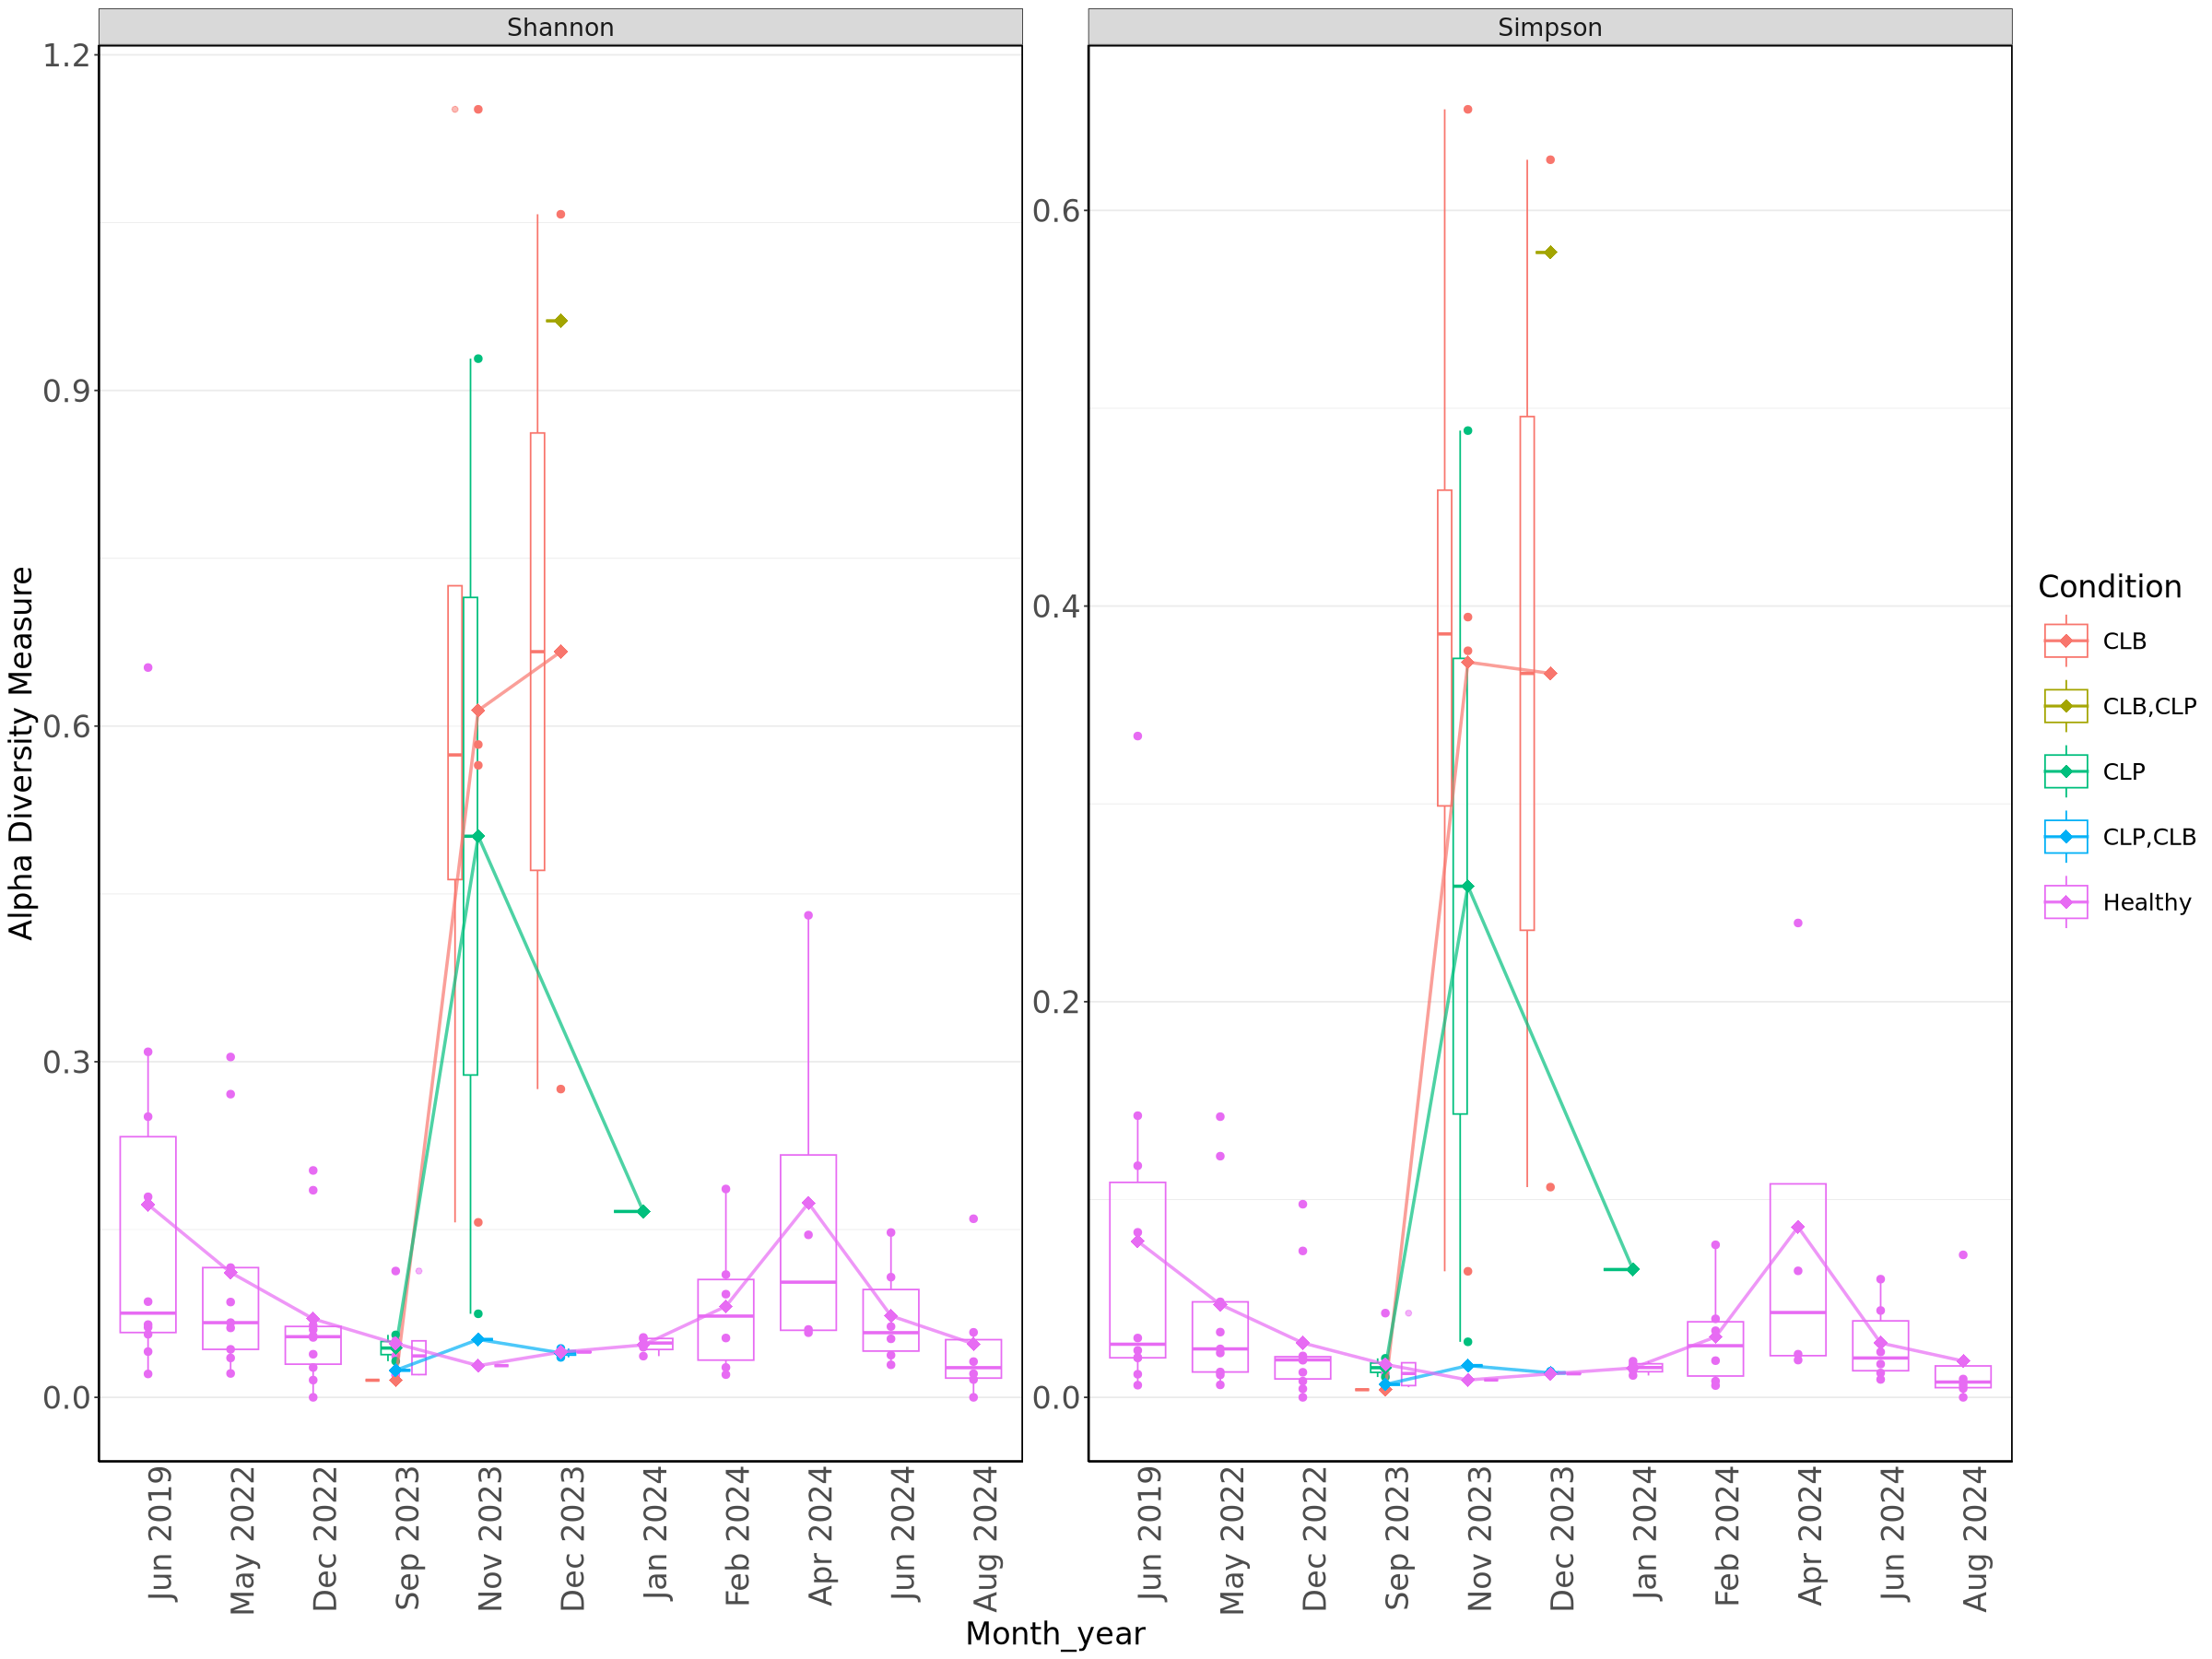

In [31]:
# Alpha diversity dot-line plot
plot_richness(ps_past_nodisease, x="Month_year", measures=c("Shannon", "Simpson"), color="Condition") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Condition), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Condition)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

### transect

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”
Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the phyloseq package.
  Please report the issue at <https://github.com/joey711/phyloseq/issues>.”


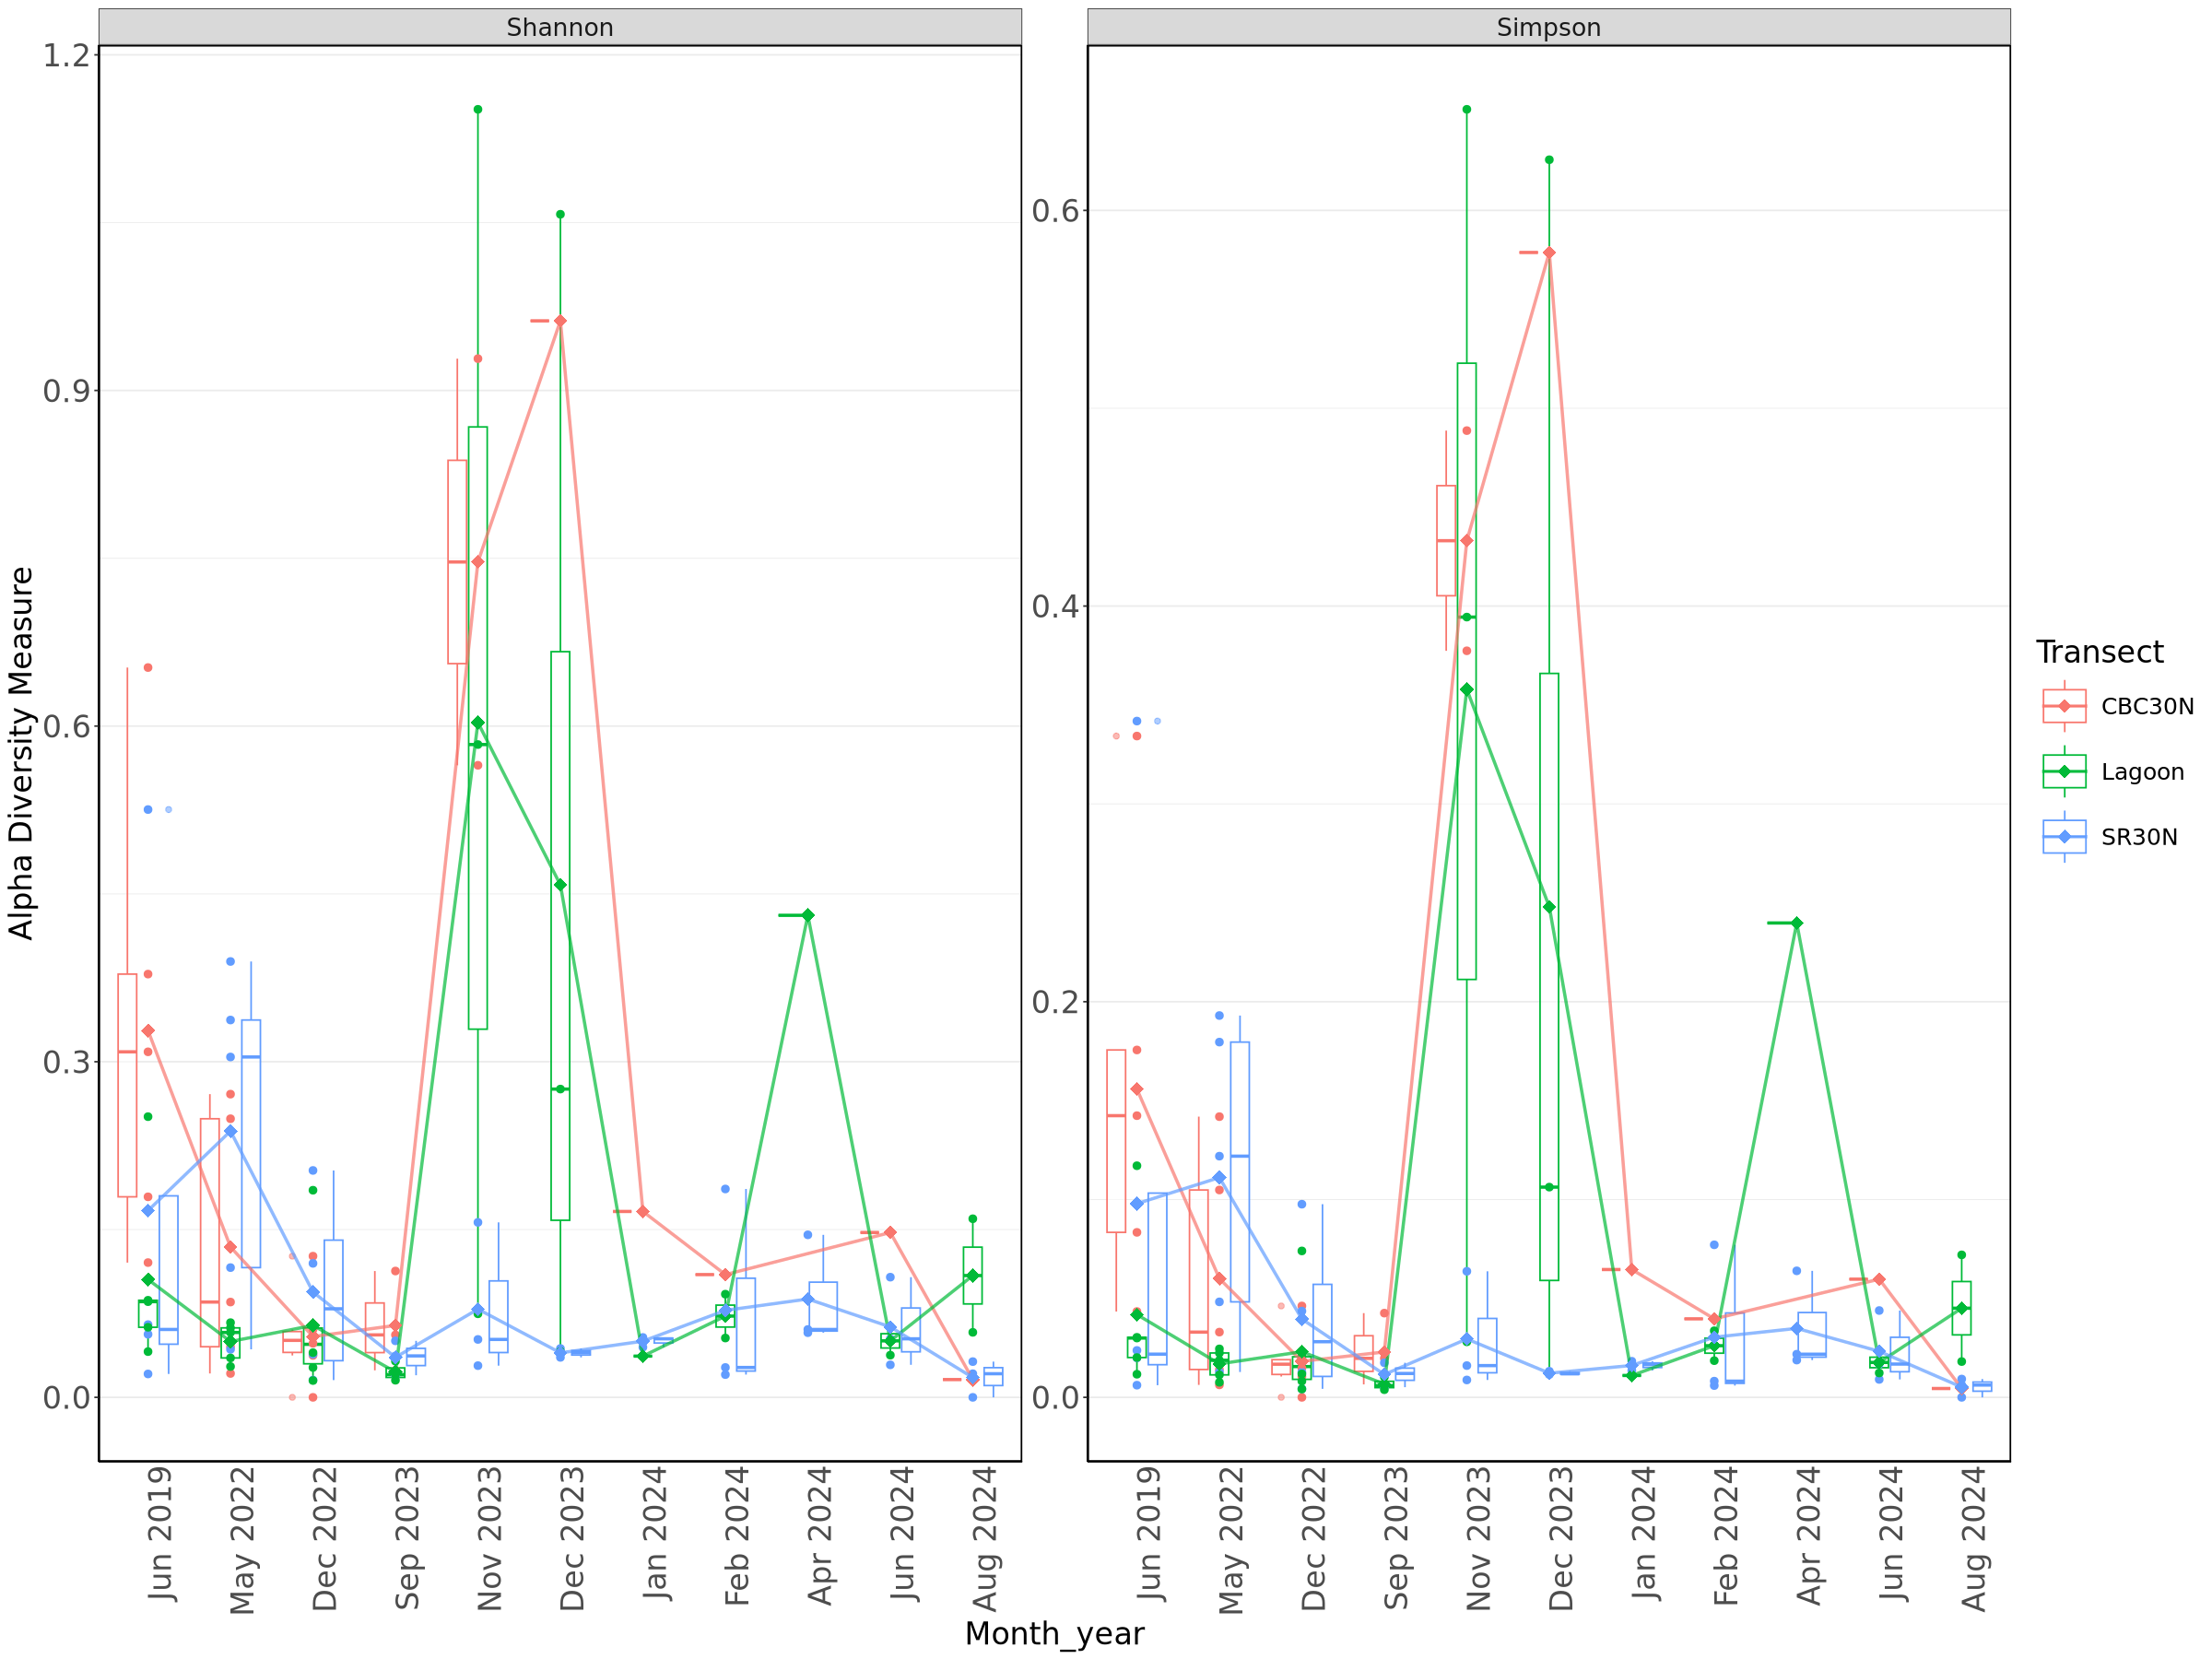

In [27]:
# Alpha diversity dot-line plot
plot_richness(ps_past_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )
     

### health_status

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


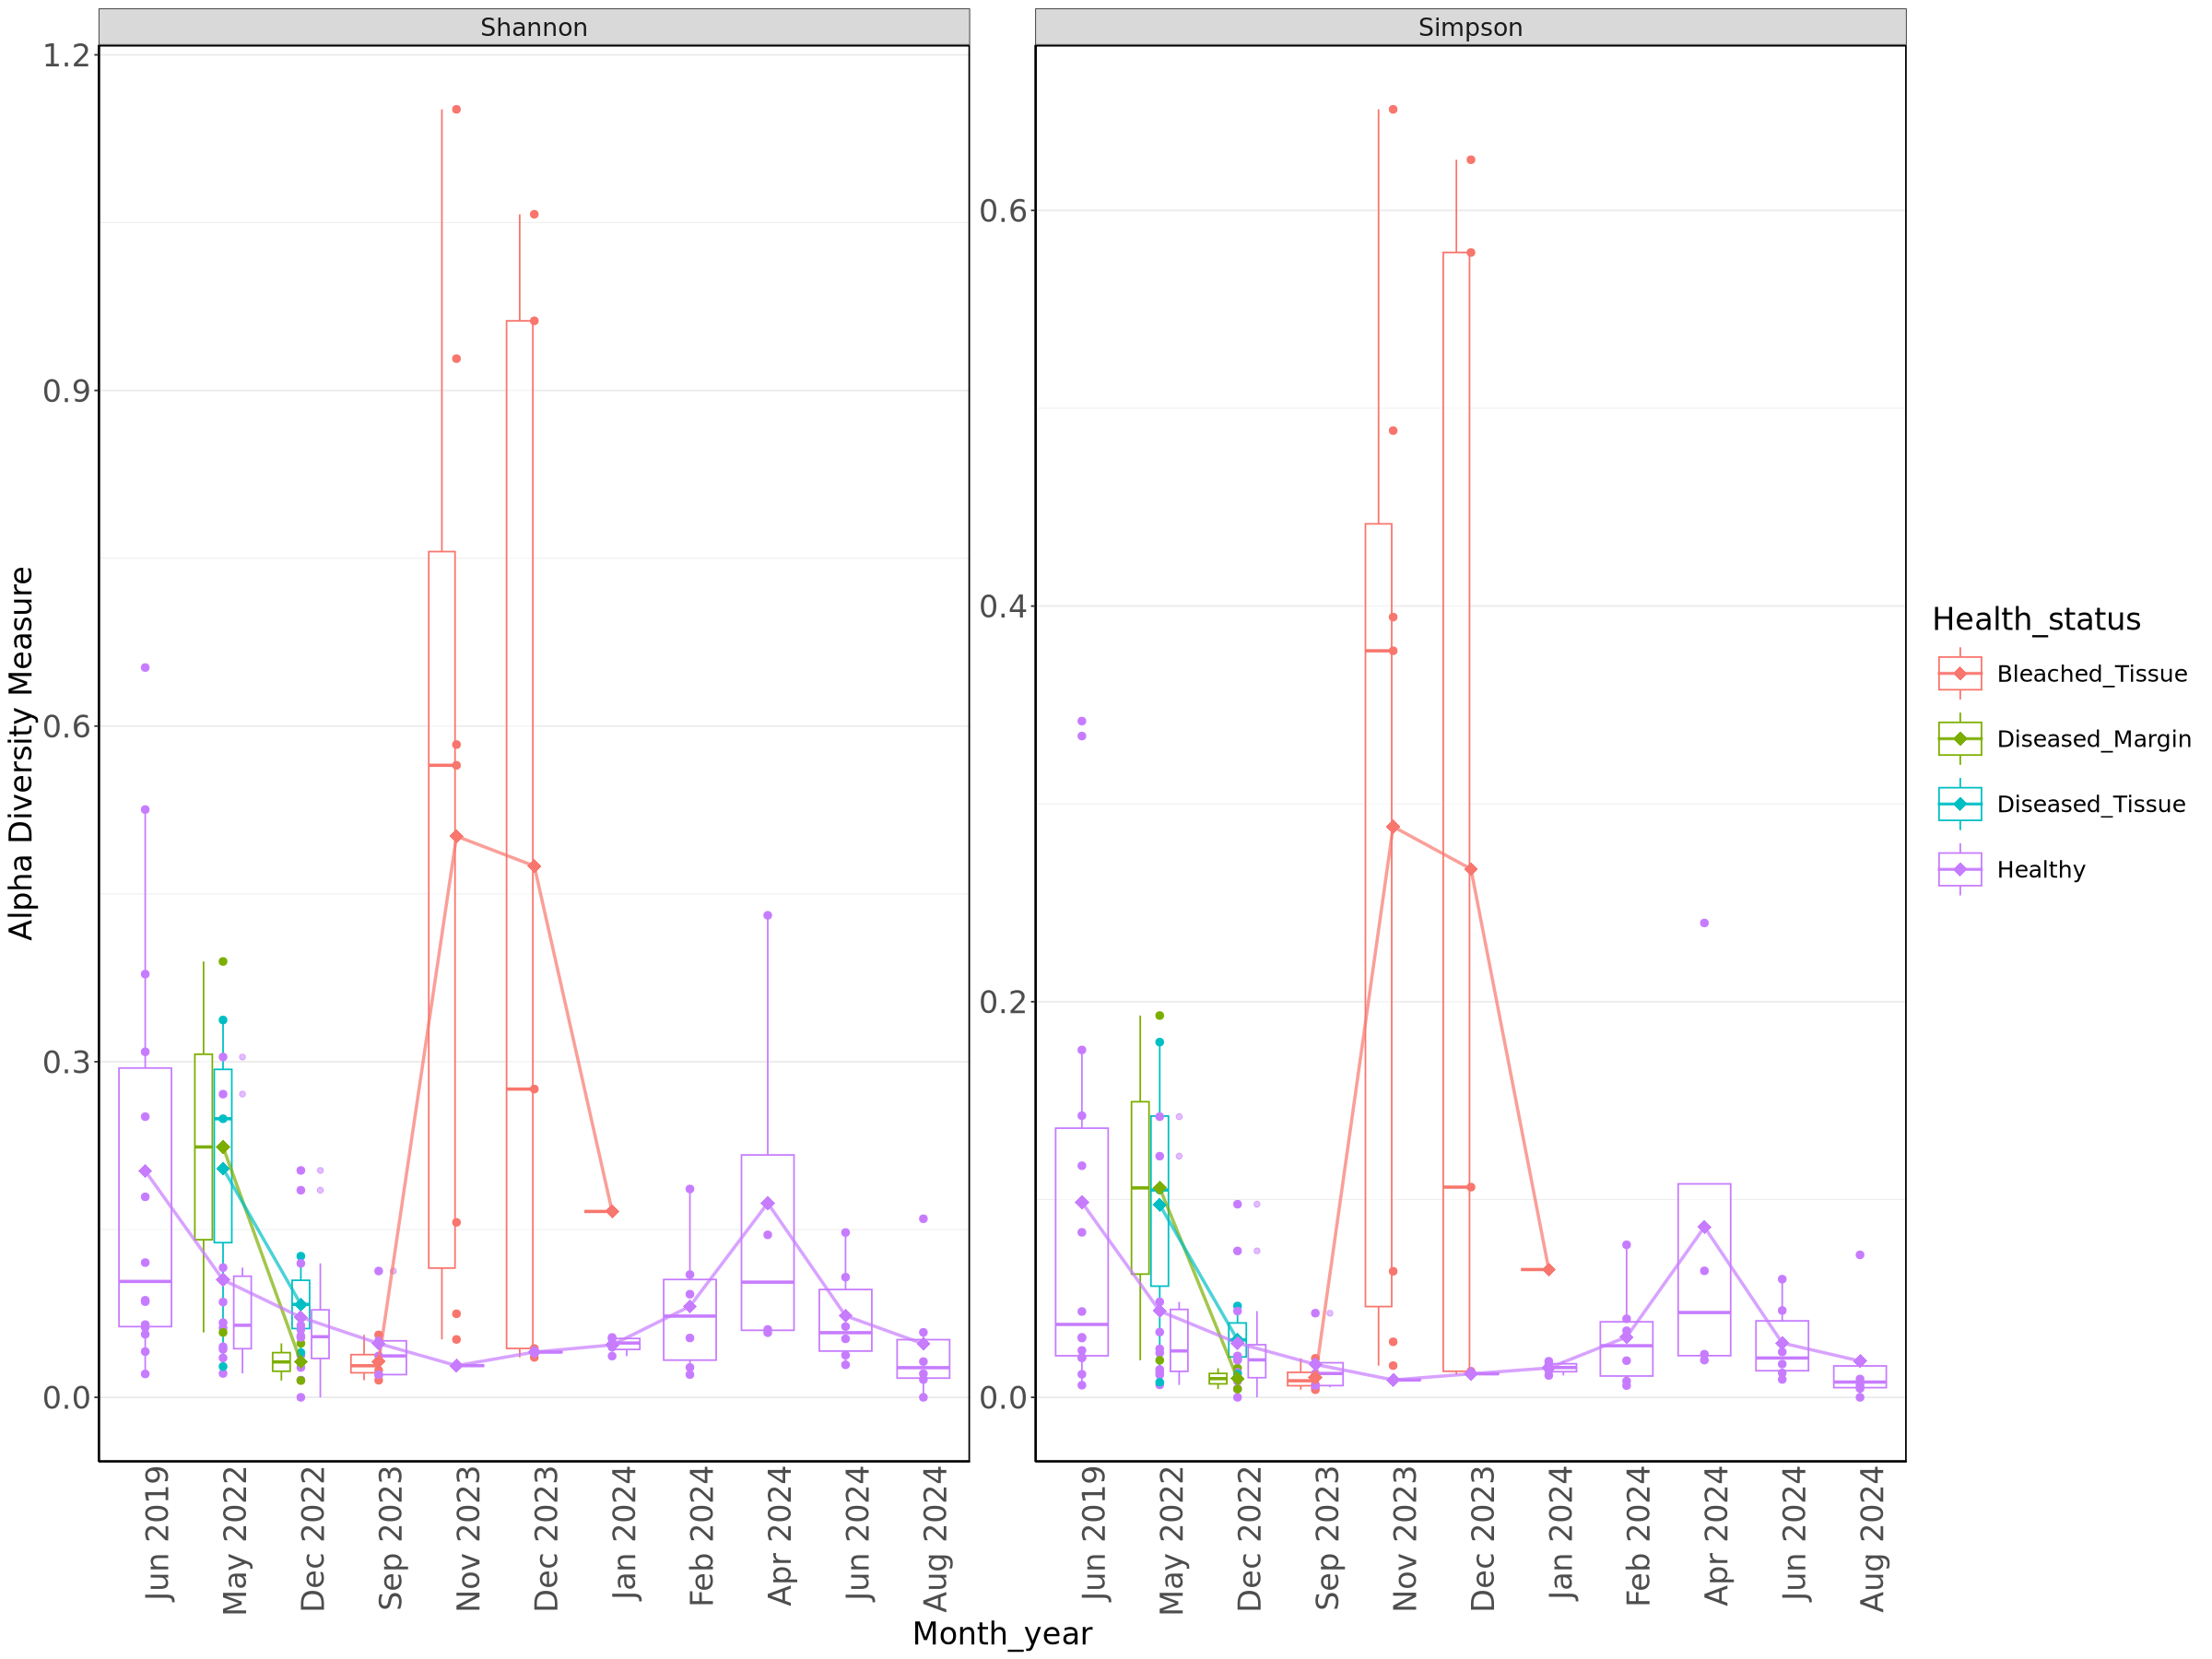

In [28]:
# Alpha diversity dot-line plot
plot_richness(ps_past_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Health_status") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION TO ADD THE MEAN AS A POINT---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Health_status), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Health_status)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

## MCAV

### transect

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


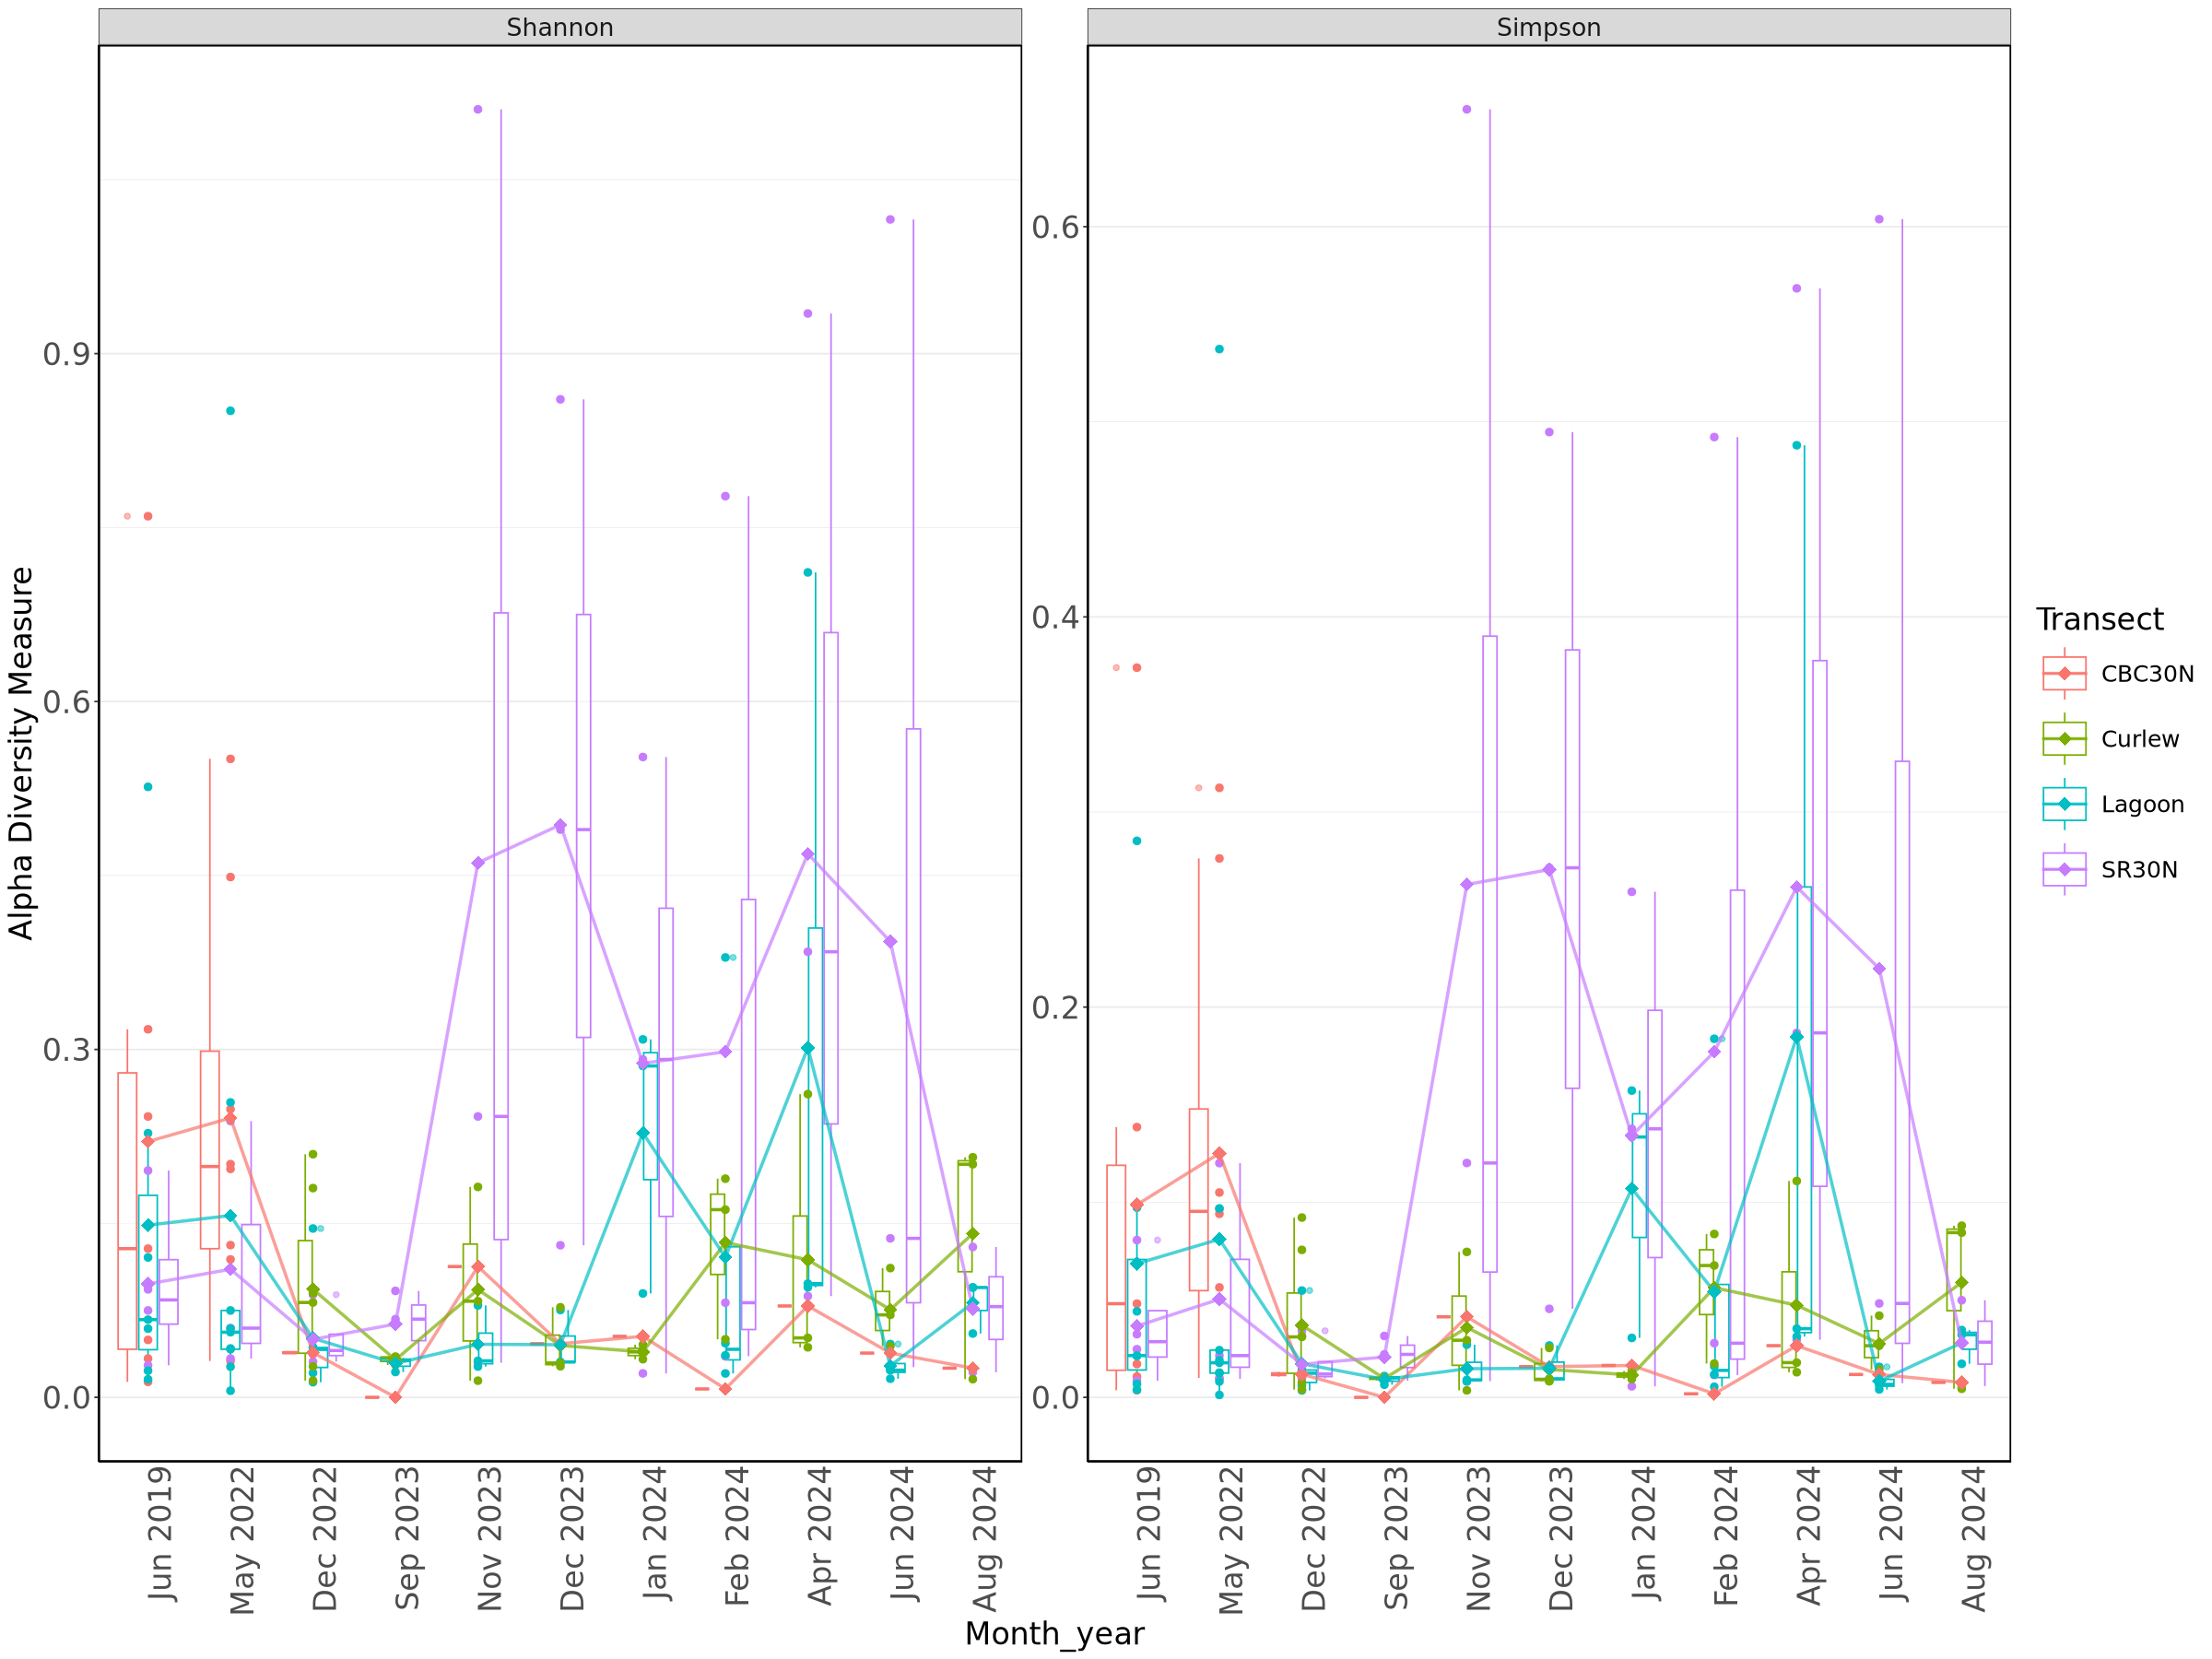

In [29]:
# Alpha diversity dot-line plot
plot_richness(ps_mcav_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Transect") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION ---
  stat_summary(
    fun = mean, 
    geom = "line", 
    aes(group = Transect), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = mean, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Transect)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )

### health status

Warning message in estimate_richness(physeq, split = TRUE, measures = measures):
“The data you have provided does not have
any singletons. This is highly suspicious. Results of richness
estimates (for example) are probably unreliable, or wrong, if you have already
trimmed low-abundance taxa from the data.

We recommended that you find the un-trimmed data and retry.”


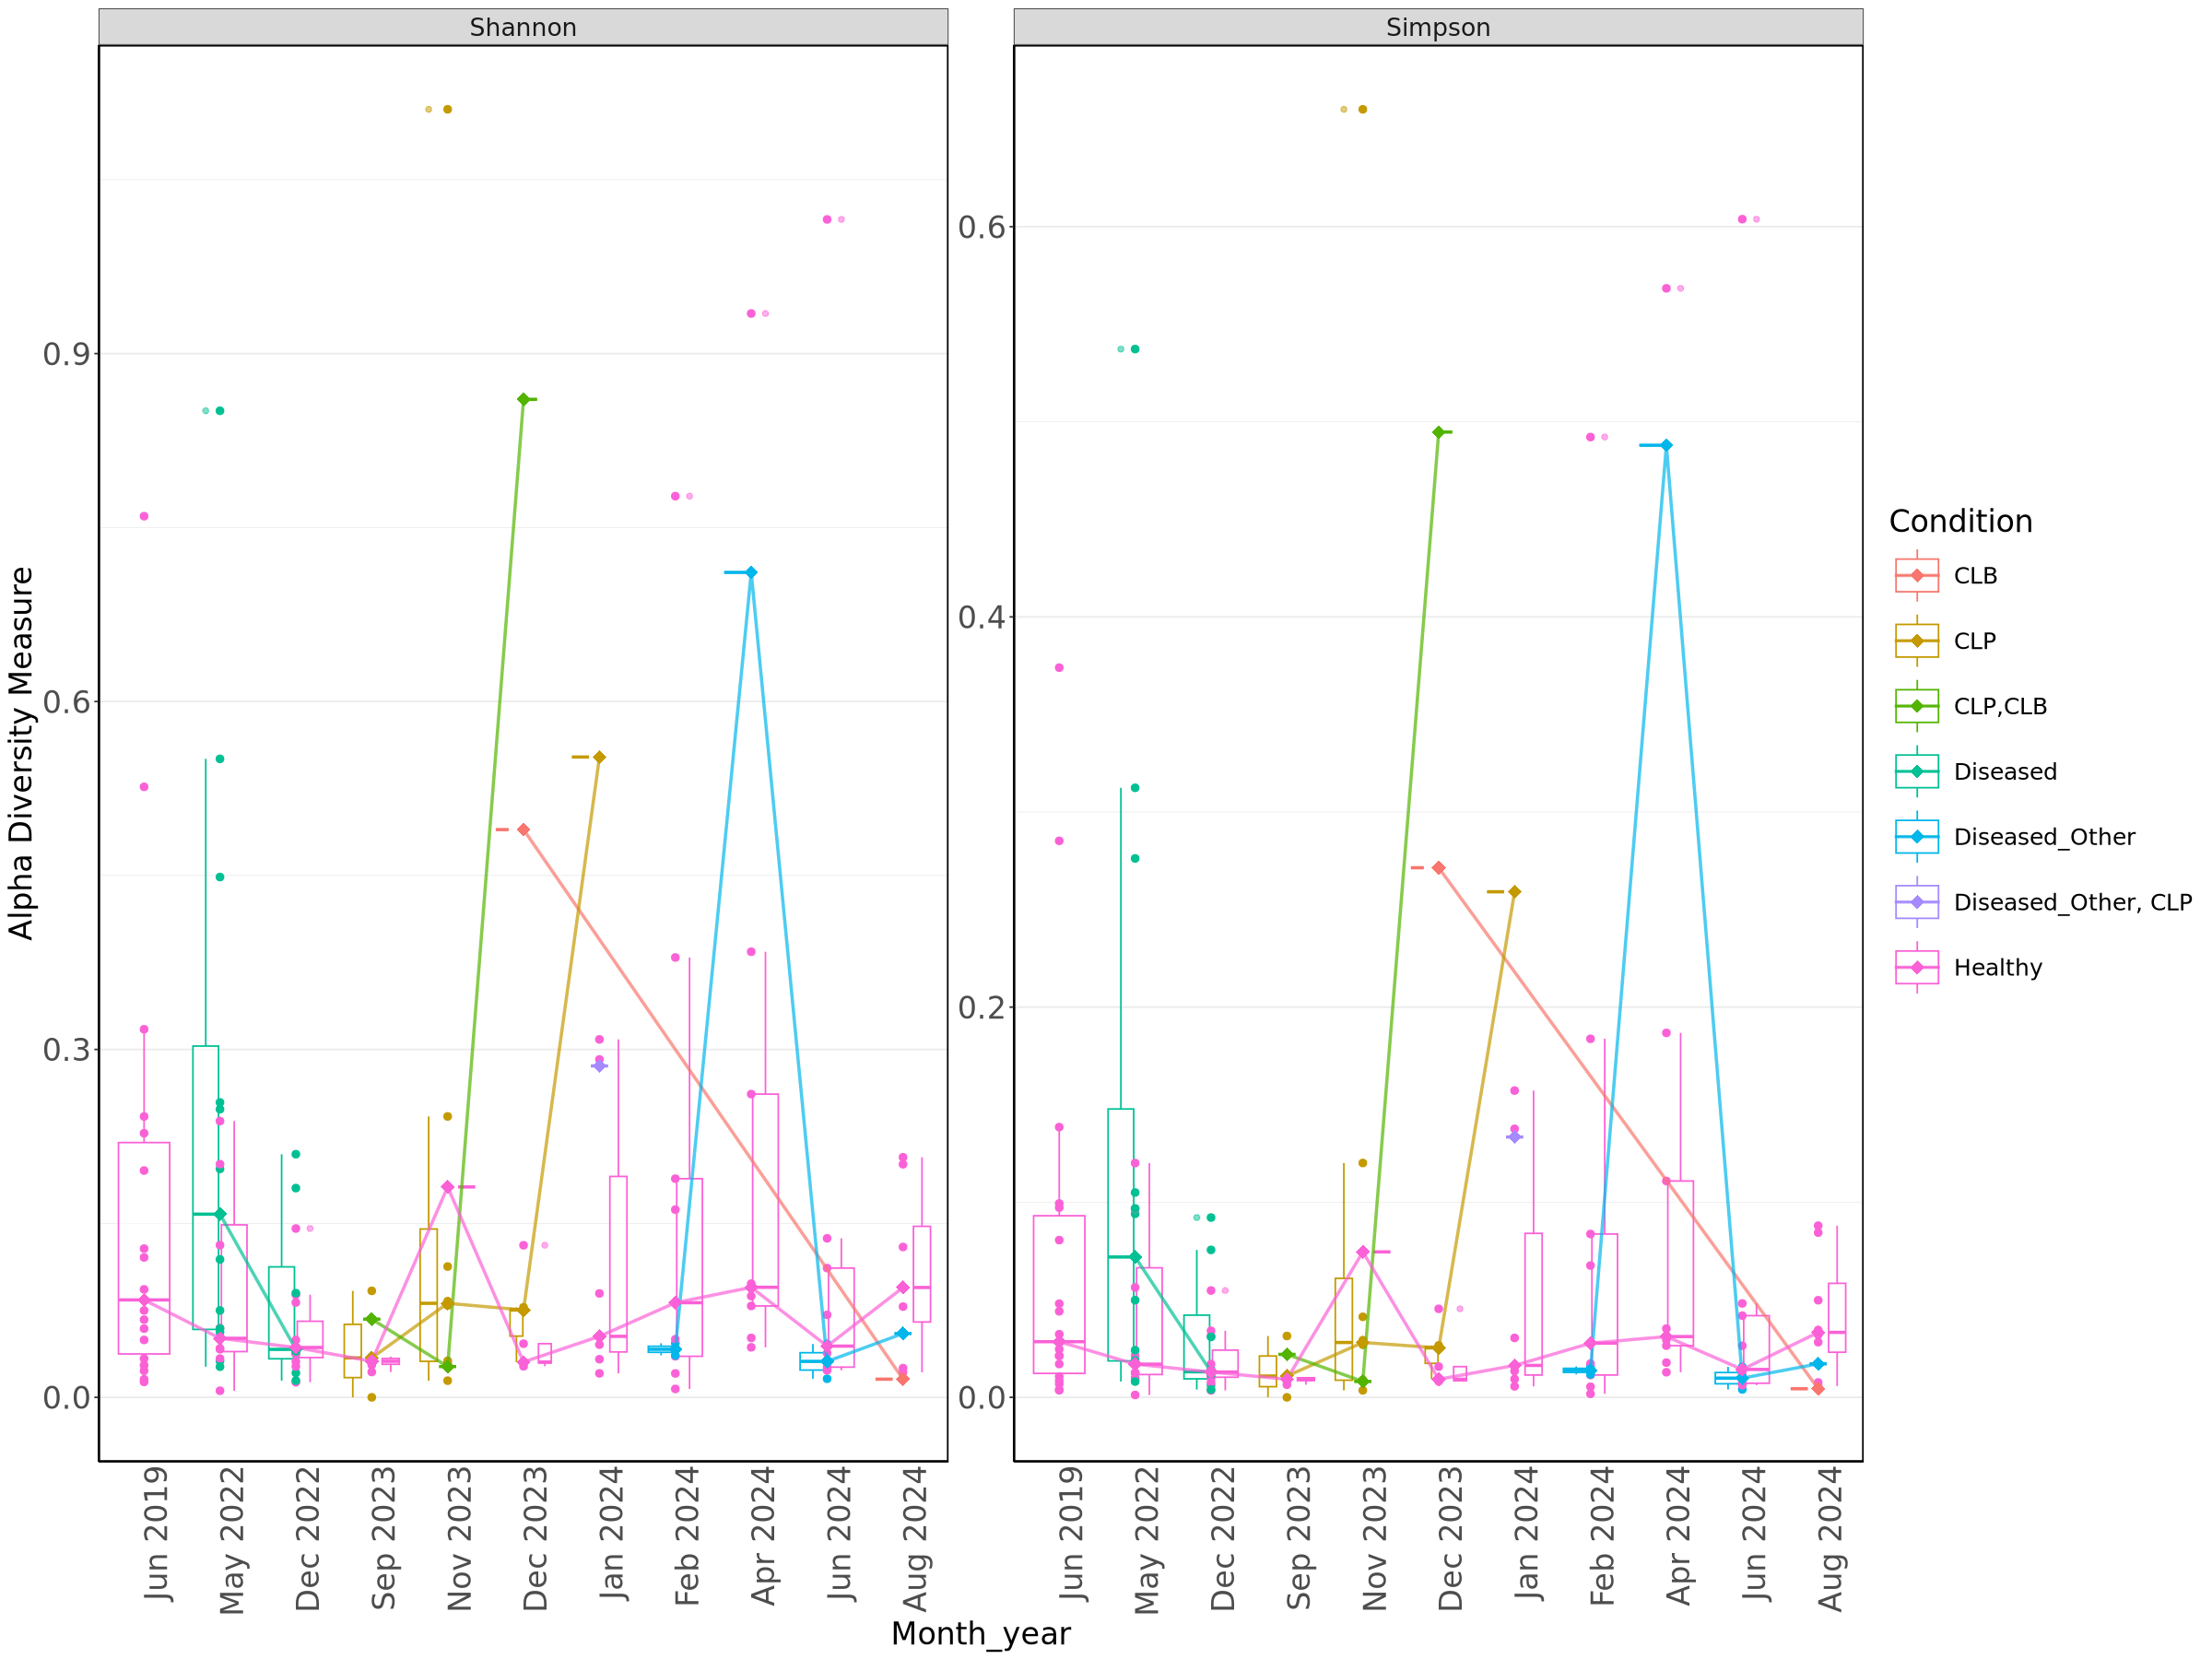

In [30]:
# Alpha diversity dot-line plot
plot_richness(ps_mcav_high, x="Month_year", measures=c("Shannon", "Simpson"), color="Condition") + 
  geom_boxplot(alpha = 0.5) + # Added alpha for better visibility of points
  geom_point(size=2) +
  # --- ADD THIS SECTION TO ADD THE MEAN AS A POINT---
  stat_summary(
    fun = median, 
    geom = "line", 
    aes(group = Condition), 
    linewidth = 1, 
    alpha = 0.7
  ) +
  stat_summary(
    fun = median, 
    geom = "point", 
    shape = 18, 
    size = 4, 
    aes(group = Condition)
  ) +
  # -------------------------
  theme_bw() +
  theme(
    legend.position = "right",
    legend.title = element_text(size = 20),
    legend.text = element_text(size = 15),
    legend.key.width = unit(1.3, "cm"),
    legend.key.height = unit(1.5, "cm"),
    panel.border = element_rect(color = "black", fill = NA, linewidth = 1),
    panel.grid.major.x = element_blank(),
    panel.grid.minor.x = element_blank(),
    axis.ticks.x = element_blank(),
    axis.line = element_line(color = "black"),
    axis.text.x = element_text(angle = 90, vjust = 1, hjust = 1, size=20),
    axis.text.y = element_text(size = 20),
    text = element_text(size = 20)
  )